## 1️⃣ Importar Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# Configuração de visualização
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', None)

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


## 2️⃣ Carregar Dados

In [8]:
# Carregar dados
df = pd.read_csv('data/lotofacil_sorteios.csv')
df['Data Sorteio'] = pd.to_datetime(df['Data Sorteio'], format='%d/%m/%Y')

print(f"✅ Dados carregados: {len(df)} concursos")
print(f"📅 Período: {df['Data Sorteio'].min().strftime('%d/%m/%Y')} até {df['Data Sorteio'].max().strftime('%d/%m/%Y')}")
print(f"🎯 Último concurso: {df['Concurso'].max()}")

✅ Dados carregados: 3584 concursos
📅 Período: 29/09/2003 até 10/01/2026
🎯 Último concurso: 3584


## 3️⃣ Configuração - Defina o Range de Concursos

In [9]:
# 🎯 CONFIGURE AQUI: Range de concursos para análise
# Use None para pegar os últimos N concursos automaticamente
CONCURSO_INICIAL = None  # ou coloque um número específico (ex: 3569)
CONCURSO_FINAL = None    # ou coloque um número específico (ex: 3583)
ULTIMOS_N = 15           # Quantos concursos mostrar (usado se INICIAL e FINAL forem None)

# Determinar range
if CONCURSO_INICIAL is None or CONCURSO_FINAL is None:
    df_filtrado = df.tail(ULTIMOS_N).copy()
    concurso_ini = df_filtrado['Concurso'].min()
    concurso_fim = df_filtrado['Concurso'].max()
else:
    df_filtrado = df[(df['Concurso'] >= CONCURSO_INICIAL) & (df['Concurso'] <= CONCURSO_FINAL)].copy()
    concurso_ini = CONCURSO_INICIAL
    concurso_fim = CONCURSO_FINAL

print(f"📊 Análise de {len(df_filtrado)} concursos")
print(f"🎯 Range: {concurso_ini} a {concurso_fim}")

📊 Análise de 15 concursos
🎯 Range: 3570 a 3584


## 4️⃣ Criar Grade de Comportamento

In [10]:
# Criar matriz de sorteios (similar à grade do site)
def criar_grade_sorteios(df_filtrado):
    """
    Cria uma matriz onde:
    - Linhas = Concursos
    - Colunas = Números (01 a 25)
    - Valores = 1 se sorteado, 0 se não
    """
    grade = pd.DataFrame()
    grade['Concurso'] = df_filtrado['Concurso']
    
    # Para cada número de 1 a 25
    for num in range(1, 26):
        col_name = f'{num:02d}'
        # Verificar se o número foi sorteado
        grade[col_name] = df_filtrado.apply(
            lambda row: num if num in [row[f'Bola{i}'] for i in range(1, 16)] else '',
            axis=1
        )
    
    # Adicionar colunas de análise
    # Contar repetições (números que saíram no sorteio anterior)
    grade['Repet.'] = 0
    
    # Soma total
    grade['Soma'] = df_filtrado.apply(
        lambda row: sum([row[f'Bola{i}'] for i in range(1, 16)]),
        axis=1
    )
    
    # Par/Ímpar
    grade['Par/Imp'] = df_filtrado.apply(
        lambda row: f"{sum(1 for i in range(1, 16) if row[f'Bola{i}'] % 2 == 0)}/{sum(1 for i in range(1, 16) if row[f'Bola{i}'] % 2 != 0)}",
        axis=1
    )
    
    return grade

grade_sorteios = criar_grade_sorteios(df_filtrado)
print("✅ Grade de sorteios criada!")
print(f"📏 Dimensões: {grade_sorteios.shape[0]} concursos x {grade_sorteios.shape[1]} colunas")

✅ Grade de sorteios criada!
📏 Dimensões: 15 concursos x 29 colunas


## 5️⃣ Calcular Estatísticas por Dezena

In [11]:
def calcular_estatisticas_dezenas(df_completo, df_filtrado):
    """
    Calcula estatísticas para cada dezena:
    - Sequência: quantas vezes seguidas saiu nos últimos concursos
    - Atrasos: quantos concursos sem sair
    - Freq.: frequência total no período filtrado
    - Média: média de aparições
    - Temp.: temperatura (Q=Quente, M=Morno, F=Frio)
    """
    estatisticas = {}
    
    # Para cada número de 1 a 25
    for num in range(1, 26):
        col_name = f'{num:02d}'
        
        # Sequência (quantas vezes seguidas saiu recentemente)
        sequencia = 0
        for idx in range(len(df_filtrado)-1, -1, -1):
            numeros_sorteados = [df_filtrado.iloc[idx][f'Bola{i}'] for i in range(1, 16)]
            if num in numeros_sorteados:
                sequencia += 1
            else:
                break
        
        # Atrasos (quantos concursos sem sair)
        atraso = 0
        if sequencia == 0:  # Só calcular se não está em sequência
            for idx in range(len(df_filtrado)-1, -1, -1):
                numeros_sorteados = [df_filtrado.iloc[idx][f'Bola{i}'] for i in range(1, 16)]
                if num not in numeros_sorteados:
                    atraso += 1
                else:
                    break
        
        # Frequência no período filtrado
        freq = sum(1 for idx in range(len(df_filtrado)) 
                  if num in [df_filtrado.iloc[idx][f'Bola{i}'] for i in range(1, 16)])
        
        # Frequência nos últimos 20 concursos (para temperatura)
        ultimos_20 = df_completo.tail(20)
        freq_20 = sum(1 for idx in range(len(ultimos_20)) 
                     if num in [ultimos_20.iloc[idx][f'Bola{i}'] for i in range(1, 16)])
        
        # Temperatura baseada na frequência dos últimos 20 concursos
        # Q (Quente): >= 13, M (Morno): 8-12, F (Frio): <= 7
        if freq_20 >= 13:
            temp = 'Q'
        elif freq_20 >= 8:
            temp = 'M'
        else:
            temp = 'F'
        
        estatisticas[col_name] = {
            'Sequência': sequencia,
            'Atrasos': atraso,
            'Freq.': freq,
            'Média': round(freq / len(df_filtrado), 1) if len(df_filtrado) > 0 else 0,
            'Temp.': temp
        }
    
    return estatisticas

stats = calcular_estatisticas_dezenas(df, df_filtrado)
print("✅ Estatísticas calculadas!")

✅ Estatísticas calculadas!


## 6️⃣ Visualizar Grade de Comportamento (Estilo Site)

In [17]:
def criar_grade_html(grade, stats):
    """
    Cria uma tabela HTML formatada similar ao site da Lotofácil
    """
    html = """<style>
    .lotofacil-table {
        border-collapse: collapse;
        font-family: Arial, sans-serif;
        font-size: 12px;
        width: 100%;
        margin: 20px 0;
    }
    .lotofacil-table th {
        background-color: #8B4789;
        color: white;
        padding: 8px 4px;
        text-align: center;
        font-weight: bold;
        border: 1px solid #999;
    }
    .lotofacil-table td {
        padding: 8px 4px;
        text-align: center;
        border: 1px solid #999;
        background-color: white;
    }
    .numero-nao-sorteado {
        background-color: #999999;
    }
    .numero-sorteado {
        background-color: white;
        font-weight: bold;
        color: #000;
    }
    .concurso-col {
        background-color: white !important;
        font-weight: bold;
        color: red;
    }
    .stats-row {
        background-color: #c8a8c7 !important;
        font-weight: bold;
        color: #000 !important;
    }
    .stats-col {
        background-color: white !important;
        color: red;
        font-weight: bold;
    }
    .temp-Q { background-color: #ff9999 !important; color: #990000; font-weight: bold; }
    .temp-M { background-color: #ffdd66 !important; color: #996600; font-weight: bold; }
    .temp-F { background-color: #99d5ff !important; color: #004d99; font-weight: bold; }
    
    /* Estilos para Sequência */
    .seq-alto { background-color: #ff6666 !important; color: white; font-weight: bold; }
    .seq-medio { background-color: #ffcc99 !important; color: #663300; font-weight: bold; }
    .seq-baixo { background-color: #e6e6e6 !important; color: #000; }
    
    /* Estilos para Atrasos */
    .atraso-alto { background-color: #ff4444 !important; color: white; font-weight: bold; }
    .atraso-medio { background-color: #ffaa66 !important; color: #663300; font-weight: bold; }
    .atraso-baixo { background-color: #ccffcc !important; color: #006600; }
    
    /* Estilos para Frequência */
    .freq-alto { background-color: #44cc44 !important; color: white; font-weight: bold; }
    .freq-medio { background-color: #99dd99 !important; color: #004400; font-weight: bold; }
    .freq-baixo { background-color: #ffffcc !important; color: #000; }
    
    /* Estilos para Média */
    .media-alto { background-color: #3399ff !important; color: white; font-weight: bold; }
    .media-medio { background-color: #99ccff !important; color: #003366; font-weight: bold; }
    .media-baixo { background-color: #e6f2ff !important; color: #000; }
    </style>
    """
    
    html += '<table class="lotofacil-table">'
    
    # Cabeçalho
    html += '<thead><tr>'
    html += '<th>Concurso</th>'
    for num in range(1, 26):
        html += f'<th>{num:02d}</th>'
    html += '<th>Repet.</th><th>Soma</th><th>Par/Imp</th>'
    html += '</tr></thead>'
    
    # Corpo - Concursos
    html += '<tbody>'
    for idx, row in grade.iterrows():
        html += '<tr>'
        html += f'<td class="concurso-col">{int(row["Concurso"])}</td>'
        
        for num in range(1, 26):
            col_name = f'{num:02d}'
            valor = row[col_name]
            if valor == '':
                html += '<td class="numero-nao-sorteado"></td>'
            else:
                html += f'<td class="numero-sorteado">{int(valor):02d}</td>'
        
        html += f'<td class="stats-col">{int(row["Repet."])}</td>'
        html += f'<td class="stats-col">{int(row["Soma"])}</td>'
        html += f'<td class="stats-col">{row["Par/Imp"]}</td>'
        html += '</tr>'
    
    # Calcular limites para classificação
    # Sequência
    sequencias = [stats[f'{n:02d}']['Sequência'] for n in range(1, 26)]
    seq_max = max(sequencias) if max(sequencias) > 0 else 1
    
    # Atrasos
    atrasos = [stats[f'{n:02d}']['Atrasos'] for n in range(1, 26)]
    atraso_max = max(atrasos) if max(atrasos) > 0 else 1
    
    # Frequência
    frequencias = [stats[f'{n:02d}']['Freq.'] for n in range(1, 26)]
    freq_min = min(frequencias)
    freq_max = max(frequencias)
    freq_range = freq_max - freq_min if freq_max > freq_min else 1
    
    # Média
    medias = [stats[f'{n:02d}']['Média'] for n in range(1, 26)]
    media_min = min(medias)
    media_max = max(medias)
    media_range = media_max - media_min if media_max > media_min else 1
    
    # Linhas de estatísticas
    stats_rows = ['Sequência', 'Atrasos', 'Freq.', 'Média', 'Temp.']
    
    for stat_name in stats_rows:
        html += '<tr class="stats-row">'
        html += f'<td style="color: #000;"><strong>{stat_name}</strong></td>'
        
        for num in range(1, 26):
            col_name = f'{num:02d}'
            valor = stats[col_name][stat_name]
            
            # Aplicar classes com base no tipo de estatística
            css_class = ''
            
            if stat_name == 'Sequência':
                if valor >= seq_max * 0.67:  # Top 33%
                    css_class = 'seq-alto'
                elif valor >= seq_max * 0.33:  # Middle 33%
                    css_class = 'seq-medio'
                else:  # Bottom 33%
                    css_class = 'seq-baixo'
                html += f'<td class="{css_class}">{valor}</td>'
                
            elif stat_name == 'Atrasos':
                if valor >= atraso_max * 0.67:  # Muito atrasado
                    css_class = 'atraso-alto'
                elif valor >= atraso_max * 0.33:  # Médio atraso
                    css_class = 'atraso-medio'
                else:  # Sem atraso
                    css_class = 'atraso-baixo'
                html += f'<td class="{css_class}">{valor}</td>'
                
            elif stat_name == 'Freq.':
                pct = (valor - freq_min) / freq_range if freq_range > 0 else 0.5
                if pct >= 0.67:  # Alta frequência
                    css_class = 'freq-alto'
                elif pct >= 0.33:  # Média frequência
                    css_class = 'freq-medio'
                else:  # Baixa frequência
                    css_class = 'freq-baixo'
                html += f'<td class="{css_class}">{valor}</td>'
                
            elif stat_name == 'Média':
                pct = (valor - media_min) / media_range if media_range > 0 else 0.5
                if pct >= 0.67:  # Alta média
                    css_class = 'media-alto'
                elif pct >= 0.33:  # Média média
                    css_class = 'media-medio'
                else:  # Baixa média
                    css_class = 'media-baixo'
                html += f'<td class="{css_class}">{valor}</td>'
                
            elif stat_name == 'Temp.':
                html += f'<td class="temp-{valor}">{valor}</td>'
        
        html += '<td style="color: #000;">-</td><td style="color: #000;">-</td><td style="color: #000;">-</td>'
        html += '</tr>'
    
    html += '</tbody></table>'
    
    return html

# Gerar e exibir tabela
html_table = criar_grade_html(grade_sorteios, stats)
display(HTML(html_table))

print("\n✅ Grade de comportamento exibida!")


Concurso,01,02,03,04,05,06,07,08,09,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,Repet.,Soma,Par/Imp
3570,01,02,03,,05,06,,,,10,11,,13,,15,,,18,19,20,21,22,,24,,0,190,7/8
3571,,02,03,04,05,06,,08,,,11,12,13,14,,,17,,,20,,22,,24,25,0,186,9/6
3572,01,02,,04,05,,07,,,10,,12,,14,15,16,17,18,19,,,22,,24,,0,186,9/6
3573,01,02,,,,,07,08,,10,11,12,,14,15,16,17,,,20,,22,23,,25,0,203,8/7
3574,01,,03,04,05,06,,08,,,,12,13,,15,16,17,18,,20,21,,,,25,0,184,7/8
3575,,02,,04,05,,07,08,09,10,,12,13,14,15,,17,,,,21,22,,,25,0,184,7/8
3576,01,02,03,,05,,07,08,,10,,,13,,,16,,18,19,,21,22,23,,25,0,193,6/9
3577,01,02,,04,05,06,,08,09,10,,12,,,,16,,18,,20,,,23,24,25,0,183,10/5
3578,,02,03,04,05,06,07,,09,10,,,,14,,,17,,19,20,,22,23,24,,0,185,8/7
3579,01,02,03,04,,,,08,,10,11,,13,,15,,17,,19,20,21,,23,,25,0,192,5/10



✅ Grade de comportamento exibida!


## 7️⃣ Legenda e Explicação

In [18]:
legenda_html = """<div style="font-family: Arial; padding: 20px; background-color: #f5f5f5; border-radius: 8px; margin: 20px 0;">
<h3 style="color: #8B4789;">📖 Legenda da Tabela</h3>

<div style="margin: 15px 0;">
    <h4>🎯 Colunas Principais:</h4>
    <ul>
        <li><strong>01 a 25:</strong> Cada coluna representa um número da Lotofácil.
            <ul>
                <li><span style="background-color: white; border: 1px solid #999; padding: 4px 8px; font-weight: bold;">01</span> = Número SORTEADO (fundo branco com o número)</li>
                <li><span style="background-color: #999999; border: 1px solid #999; padding: 4px 12px;">&nbsp;</span> = Número NÃO sorteado (fundo cinza escuro)</li>
            </ul>
        </li>
        <li><strong>Repet.:</strong> Quantidade de números que repetiram do sorteio anterior.</li>
        <li><strong>Soma:</strong> Soma total dos 15 números sorteados.</li>
        <li><strong>Par/Imp:</strong> Proporção de números pares e ímpares (formato: Pares/Ímpares).</li>
    </ul>
</div>

<div style="margin: 15px 0;">
    <h4>📊 Estatísticas por Dezena:</h4>
    <ul>
        <li><strong>Sequência:</strong> Quantas vezes seguidas o número foi sorteado nos concursos mais recentes.
            <ul>
                <li><span style="background-color: #ff6666; color: white; padding: 2px 8px; border-radius: 3px; font-weight: bold;">Alto</span> = Em sequência forte (3-4 vezes)</li>
                <li><span style="background-color: #ffcc99; color: #663300; padding: 2px 8px; border-radius: 3px; font-weight: bold;">Médio</span> = Sequência moderada (1-2 vezes)</li>
                <li><span style="background-color: #e6e6e6; color: #666; padding: 2px 8px; border-radius: 3px;">Baixo</span> = Sem sequência (0 vezes)</li>
            </ul>
        </li>
        <li><strong>Atrasos:</strong> Há quantos concursos o número não é sorteado.
            <ul>
                <li><span style="background-color: #ff4444; color: white; padding: 2px 8px; border-radius: 3px; font-weight: bold;">Alto</span> = Muito atrasado (3-4+ concursos)</li>
                <li><span style="background-color: #ffaa66; color: #663300; padding: 2px 8px; border-radius: 3px; font-weight: bold;">Médio</span> = Atraso moderado (1-2 concursos)</li>
                <li><span style="background-color: #ccffcc; color: #006600; padding: 2px 8px; border-radius: 3px;">Baixo</span> = Sem atraso (saiu recentemente)</li>
            </ul>
        </li>
        <li><strong>Freq.:</strong> Total de vezes que o número foi sorteado no período analisado.
            <ul>
                <li><span style="background-color: #44cc44; color: white; padding: 2px 8px; border-radius: 3px; font-weight: bold;">Alta</span> = Frequência alta no período</li>
                <li><span style="background-color: #99dd99; color: #004400; padding: 2px 8px; border-radius: 3px; font-weight: bold;">Média</span> = Frequência média</li>
                <li><span style="background-color: #ffffcc; color: #666600; padding: 2px 8px; border-radius: 3px;">Baixa</span> = Frequência baixa no período</li>
            </ul>
        </li>
        <li><strong>Média:</strong> Média de aparições do número por concurso.
            <ul>
                <li><span style="background-color: #3399ff; color: white; padding: 2px 8px; border-radius: 3px; font-weight: bold;">Alta</span> = Acima de 0.6 por concurso</li>
                <li><span style="background-color: #99ccff; color: #003366; padding: 2px 8px; border-radius: 3px; font-weight: bold;">Média</span> = Entre 0.4 e 0.6</li>
                <li><span style="background-color: #e6f2ff; color: #336699; padding: 2px 8px; border-radius: 3px;">Baixa</span> = Abaixo de 0.4</li>
            </ul>
        </li>
        <li><strong>Temp.:</strong> Temperatura do número baseada nos últimos 20 concursos:
            <ul>
                <li><span style="background-color: #ff9999; color: #990000; padding: 2px 8px; border-radius: 3px; font-weight: bold;">Q</span> = Quente (≥13 vezes nos últimos 20)</li>
                <li><span style="background-color: #ffdd66; color: #996600; padding: 2px 8px; border-radius: 3px; font-weight: bold;">M</span> = Morno (8-12 vezes nos últimos 20)</li>
                <li><span style="background-color: #99d5ff; color: #004d99; padding: 2px 8px; border-radius: 3px; font-weight: bold;">F</span> = Frio (≤7 vezes nos últimos 20)</li>
            </ul>
        </li>
    </ul>
</div>

<div style="margin: 15px 0; padding: 10px; background-color: #fff; border-left: 4px solid #8B4789;">
    <h4>💡 Dica de Uso:</h4>
    <p>Modifique as variáveis <code>CONCURSO_INICIAL</code>, <code>CONCURSO_FINAL</code> ou <code>ULTIMOS_N</code> na seção 3 para analisar diferentes períodos.</p>
    <p><strong>Novo:</strong> As células agora têm cores de contraste para facilitar a identificação rápida de valores extremos!</p>
</div>
</div>
"""

display(HTML(legenda_html))


## 8️⃣ Análise Resumida por Temperatura

In [19]:
# Agrupar números por temperatura
quentes = []
mornos = []
frios = []

for num in range(1, 26):
    col_name = f'{num:02d}'
    temp = stats[col_name]['Temp.']
    freq = stats[col_name]['Freq.']
    
    if temp == 'Q':
        quentes.append((num, freq))
    elif temp == 'M':
        mornos.append((num, freq))
    else:
        frios.append((num, freq))

# Ordenar por frequência
quentes.sort(key=lambda x: x[1], reverse=True)
mornos.sort(key=lambda x: x[1], reverse=True)
frios.sort(key=lambda x: x[1], reverse=True)

print("🔥 ANÁLISE DE TEMPERATURA DOS NÚMEROS")
print("="*70)

print(f"\n🔴 NÚMEROS QUENTES (Freq. ≥13 nos últimos 20): {len(quentes)} números")
if quentes:
    print("   Números:", ', '.join([f"{num:02d}({freq})" for num, freq in quentes]))
else:
    print("   Nenhum número quente no período.")

print(f"\n🟡 NÚMEROS MORNOS (Freq. 8-12 nos últimos 20): {len(mornos)} números")
if mornos:
    print("   Números:", ', '.join([f"{num:02d}({freq})" for num, freq in mornos]))
else:
    print("   Nenhum número morno no período.")

print(f"\n🔵 NÚMEROS FRIOS (Freq. ≤7 nos últimos 20): {len(frios)} números")
if frios:
    print("   Números:", ', '.join([f"{num:02d}({freq})" for num, freq in frios]))
else:
    print("   Nenhum número frio no período.")

print("\n" + "="*70)

🔥 ANÁLISE DE TEMPERATURA DOS NÚMEROS

🔴 NÚMEROS QUENTES (Freq. ≥13 nos últimos 20): 11 números
   Números: 02(13), 04(11), 05(11), 08(11), 10(11), 25(11), 13(10), 15(10), 20(10), 01(9), 24(8)

🟡 NÚMEROS MORNOS (Freq. 8-12 nos últimos 20): 14 números
   Números: 12(10), 06(9), 16(9), 17(9), 22(9), 23(9), 03(8), 07(8), 21(8), 09(7), 18(7), 14(6), 19(6), 11(5)

🔵 NÚMEROS FRIOS (Freq. ≤7 nos últimos 20): 0 números
   Nenhum número frio no período.



## 9️⃣ Top 10 Números com Maior Atraso

In [20]:
# Listar números com maior atraso
atrasos_lista = []
for num in range(1, 26):
    col_name = f'{num:02d}'
    atraso = stats[col_name]['Atrasos']
    temp = stats[col_name]['Temp.']
    atrasos_lista.append((num, atraso, temp))

# Ordenar por atraso (maior primeiro)
atrasos_lista.sort(key=lambda x: x[1], reverse=True)

print("⏰ TOP 10 NÚMEROS COM MAIOR ATRASO")
print("="*70)
print(f"{'Posição':<10} {'Número':<10} {'Atraso':<15} {'Temperatura'}")
print("-"*70)

for i, (num, atraso, temp) in enumerate(atrasos_lista[:10], 1):
    temp_emoji = '🔴' if temp == 'Q' else ('🟡' if temp == 'M' else '🔵')
    print(f"{i:<10} {num:02d}{'':<8} {atraso} concursos{'':<5} {temp_emoji} {temp}")

print("="*70)

⏰ TOP 10 NÚMEROS COM MAIOR ATRASO
Posição    Número     Atraso          Temperatura
----------------------------------------------------------------------
1          19         4 concursos      🟡 M
2          05         2 concursos      🔴 Q
3          11         2 concursos      🟡 M
4          03         1 concursos      🟡 M
5          06         1 concursos      🟡 M
6          10         1 concursos      🔴 Q
7          12         1 concursos      🟡 M
8          14         1 concursos      🟡 M
9          22         1 concursos      🟡 M
10         24         1 concursos      🔴 Q


## 🔟 Visualização Gráfica - Frequência por Dezena

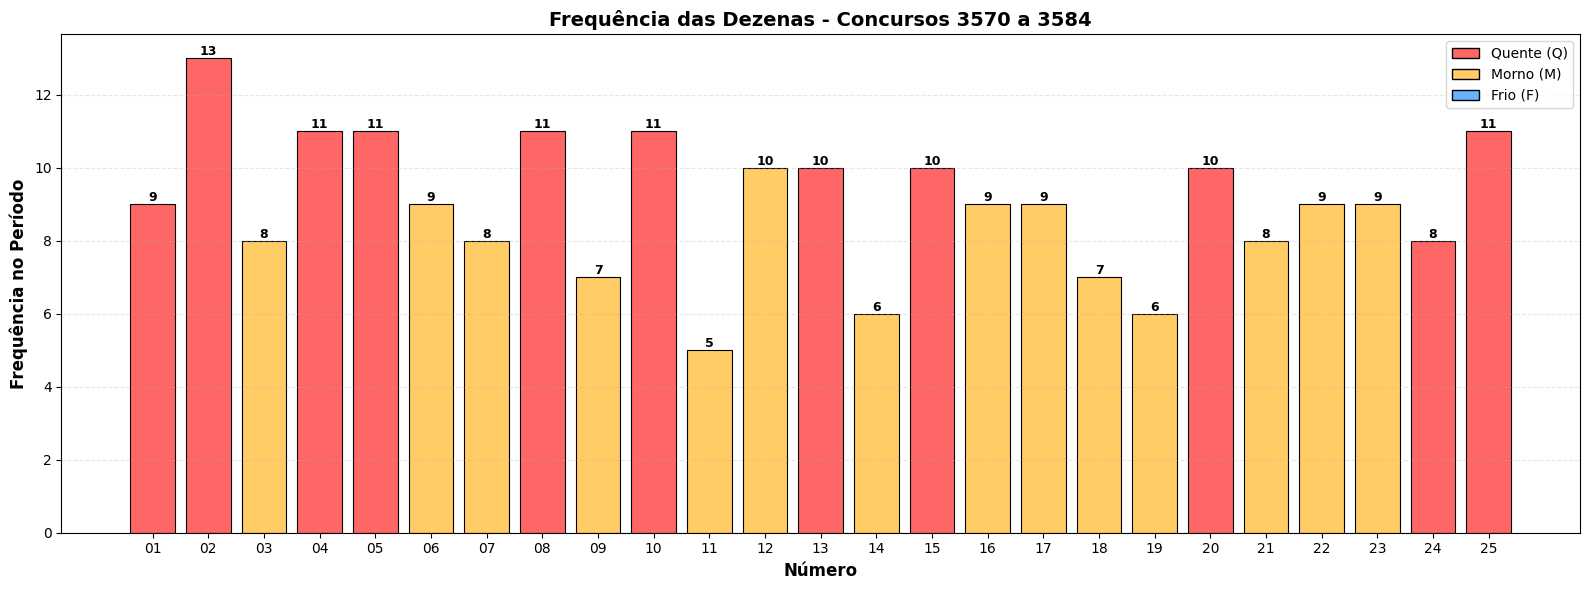


✅ Gráfico de frequências gerado!


In [21]:
# Preparar dados para gráfico
numeros = list(range(1, 26))
frequencias = [stats[f'{num:02d}']['Freq.'] for num in numeros]
temperaturas = [stats[f'{num:02d}']['Temp.'] for num in numeros]

# Cores baseadas na temperatura
cores = []
for temp in temperaturas:
    if temp == 'Q':
        cores.append('#ff6666')  # Vermelho para quente
    elif temp == 'M':
        cores.append('#ffcc66')  # Amarelo para morno
    else:
        cores.append('#66b3ff')  # Azul para frio

# Criar gráfico
fig, ax = plt.subplots(figsize=(16, 6))
bars = ax.bar(numeros, frequencias, color=cores, edgecolor='black', linewidth=0.8)

# Customização
ax.set_xlabel('Número', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequência no Período', fontsize=12, fontweight='bold')
ax.set_title(f'Frequência das Dezenas - Concursos {concurso_ini} a {concurso_fim}', 
             fontsize=14, fontweight='bold')
ax.set_xticks(numeros)
ax.set_xticklabels([f'{n:02d}' for n in numeros])
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Adicionar valores nas barras
for bar, freq in zip(bars, frequencias):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(freq)}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Legenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#ff6666', edgecolor='black', label='Quente (Q)'),
    Patch(facecolor='#ffcc66', edgecolor='black', label='Morno (M)'),
    Patch(facecolor='#66b3ff', edgecolor='black', label='Frio (F)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

print("\n✅ Gráfico de frequências gerado!")

## 1️⃣1️⃣ Análise de Combinações com Soma Específica

Quantas combinações de 15 números (do domínio 1 a 25) formam um somatório de valor 203?

In [23]:
from itertools import combinations
import time

# Parâmetros da análise
SOMA_ALVO = 212
QUANTIDADE_NUMEROS = 15
NUMEROS_DISPONIVEIS = list(range(1, 26))

print("🔢 ANÁLISE DE COMBINAÇÕES COM SOMA ESPECÍFICA")
print("="*70)
print(f"\n📊 Parâmetros:")
print(f"   Domínio: {NUMEROS_DISPONIVEIS[0]} a {NUMEROS_DISPONIVEIS[-1]} ({len(NUMEROS_DISPONIVEIS)} números)")
print(f"   Quantidade por combinação: {QUANTIDADE_NUMEROS} números")
print(f"   Soma alvo: {SOMA_ALVO}")
print(f"\n⏳ Processando todas as combinações possíveis...")

# Iniciar contagem
inicio = time.time()
combinacoes_validas = []
total_combinacoes = 0

# Gerar e testar todas as combinações
for combo in combinations(NUMEROS_DISPONIVEIS, QUANTIDADE_NUMEROS):
    total_combinacoes += 1
    soma = sum(combo)
    
    if soma == SOMA_ALVO:
        combinacoes_validas.append(combo)
    
    # Mostrar progresso a cada 100.000 combinações
    if total_combinacoes % 100000 == 0:
        print(f"   Processadas: {total_combinacoes:,} combinações...")

fim = time.time()
tempo_decorrido = fim - inicio

# Resultados
print(f"\n✅ Processamento concluído em {tempo_decorrido:.2f} segundos")
print("\n" + "="*70)
print("📈 RESULTADOS")
print("="*70)
print(f"\n🎯 Total de combinações possíveis: {total_combinacoes:,}")
print(f"✅ Combinações com soma = {SOMA_ALVO}: {len(combinacoes_validas):,}")
print(f"📊 Percentual: {(len(combinacoes_validas)/total_combinacoes)*100:.4f}%")

if len(combinacoes_validas) > 0:
    print(f"\n💡 Isso significa que de cada {int(total_combinacoes/len(combinacoes_validas))} combinações,")
    print(f"   aproximadamente 1 tem soma igual a {SOMA_ALVO}")

print("\n" + "="*70)

🔢 ANÁLISE DE COMBINAÇÕES COM SOMA ESPECÍFICA

📊 Parâmetros:
   Domínio: 1 a 25 (25 números)
   Quantidade por combinação: 15 números
   Soma alvo: 212

⏳ Processando todas as combinações possíveis...
   Processadas: 100,000 combinações...
   Processadas: 200,000 combinações...
   Processadas: 300,000 combinações...
   Processadas: 400,000 combinações...
   Processadas: 500,000 combinações...
   Processadas: 600,000 combinações...
   Processadas: 700,000 combinações...
   Processadas: 800,000 combinações...
   Processadas: 900,000 combinações...
   Processadas: 1,000,000 combinações...
   Processadas: 1,100,000 combinações...
   Processadas: 1,200,000 combinações...
   Processadas: 1,300,000 combinações...
   Processadas: 1,400,000 combinações...
   Processadas: 1,500,000 combinações...
   Processadas: 1,600,000 combinações...
   Processadas: 1,700,000 combinações...
   Processadas: 1,800,000 combinações...
   Processadas: 1,900,000 combinações...
   Processadas: 2,000,000 combinações..

### 📋 Primeiras 10 Combinações com Soma = 200

In [24]:
# Mostrar as primeiras combinações válidas
if len(combinacoes_validas) > 0:
    print("🎲 PRIMEIRAS 10 COMBINAÇÕES COM SOMA = 209")
    print("="*70)
    
    for i, combo in enumerate(combinacoes_validas[:10], 1):
        numeros_formatados = ', '.join([f'{n:02d}' for n in combo])
        soma = sum(combo)
        print(f"\n{i:2d}. [{numeros_formatados}]")
        print(f"    Soma: {soma} | Menor: {min(combo):02d} | Maior: {max(combo):02d} | Amplitude: {max(combo)-min(combo)}")
    
    if len(combinacoes_validas) > 10:
        print(f"\n... e mais {len(combinacoes_validas) - 10:,} combinações")
    
    print("\n" + "="*70)
else:
    print("❌ Nenhuma combinação encontrada com a soma especificada.")

🎲 PRIMEIRAS 10 COMBINAÇÕES COM SOMA = 209

 1. [01, 02, 03, 04, 05, 08, 17, 18, 19, 20, 21, 22, 23, 24, 25]
    Soma: 212 | Menor: 01 | Maior: 25 | Amplitude: 24

 2. [01, 02, 03, 04, 05, 09, 16, 18, 19, 20, 21, 22, 23, 24, 25]
    Soma: 212 | Menor: 01 | Maior: 25 | Amplitude: 24

 3. [01, 02, 03, 04, 05, 10, 15, 18, 19, 20, 21, 22, 23, 24, 25]
    Soma: 212 | Menor: 01 | Maior: 25 | Amplitude: 24

 4. [01, 02, 03, 04, 05, 10, 16, 17, 19, 20, 21, 22, 23, 24, 25]
    Soma: 212 | Menor: 01 | Maior: 25 | Amplitude: 24

 5. [01, 02, 03, 04, 05, 11, 14, 18, 19, 20, 21, 22, 23, 24, 25]
    Soma: 212 | Menor: 01 | Maior: 25 | Amplitude: 24

 6. [01, 02, 03, 04, 05, 11, 15, 17, 19, 20, 21, 22, 23, 24, 25]
    Soma: 212 | Menor: 01 | Maior: 25 | Amplitude: 24

 7. [01, 02, 03, 04, 05, 11, 16, 17, 18, 20, 21, 22, 23, 24, 25]
    Soma: 212 | Menor: 01 | Maior: 25 | Amplitude: 24

 8. [01, 02, 03, 04, 05, 12, 13, 18, 19, 20, 21, 22, 23, 24, 25]
    Soma: 212 | Menor: 01 | Maior: 25 | Amplitude: 2

### 📊 Estatísticas das Combinações Válidas

In [27]:
# Análise estatística das combinações válidas
if len(combinacoes_validas) > 0:
    print("📊 ANÁLISE ESTATÍSTICA DAS COMBINAÇÕES VÁLIDAS")
    print("="*70)
    
    # Frequência de cada número nas combinações válidas
    frequencia_numeros = {}
    for num in range(1, 26):
        frequencia_numeros[num] = sum(1 for combo in combinacoes_validas if num in combo)
    
    # Ordenar por frequência
    numeros_ordenados = sorted(frequencia_numeros.items(), key=lambda x: x[1], reverse=True)
    
    print(f"\n🔢 FREQUÊNCIA DOS NÚMEROS NAS COMBINAÇÕES VÁLIDAS:")
    print(f"   Total de combinações válidas: {len(combinacoes_validas):,}\n")
    
    print("   Número | Frequência | Percentual | Barra")
    print("   " + "-"*60)
    
    for num, freq in numeros_ordenados:
        pct = (freq / len(combinacoes_validas)) * 100
        barra = '█' * int(pct / 2)
        print(f"   {num:02d}     | {freq:10,} | {pct:6.2f}%    | {barra}")
    
    # Estatísticas gerais
    print("\n" + "="*70)
    print("📈 ESTATÍSTICAS GERAIS:")
    print("="*70)
    
    frequencias = list(frequencia_numeros.values())
    print(f"\n   Frequência mínima: {min(frequencias):,} vezes")
    print(f"   Frequência máxima: {max(frequencias):,} vezes")
    print(f"   Frequência média:  {sum(frequencias)/len(frequencias):,.1f} vezes")
    
    # Números mais e menos frequentes
    mais_frequentes = [num for num, freq in numeros_ordenados[:5]]
    menos_frequentes = [num for num, freq in numeros_ordenados[-5:]]
    
    print(f"\n   5 números MAIS frequentes: {', '.join([f'{n:02d}' for n in mais_frequentes])}")
    print(f"   5 números MENOS frequentes: {', '.join([f'{n:02d}' for n in menos_frequentes])}")
    
    print("\n" + "="*70)
else:
    print("❌ Sem dados para análise estatística.")

📊 ANÁLISE ESTATÍSTICA DAS COMBINAÇÕES VÁLIDAS

🔢 FREQUÊNCIA DOS NÚMEROS NAS COMBINAÇÕES VÁLIDAS:
   Total de combinações válidas: 68,462

   Número | Frequência | Percentual | Barra
   ------------------------------------------------------------
   25     |     44,916 |  65.61%    | ████████████████████████████████
   24     |     44,407 |  64.86%    | ████████████████████████████████
   23     |     43,967 |  64.22%    | ████████████████████████████████
   22     |     43,548 |  63.61%    | ███████████████████████████████
   21     |     43,178 |  63.07%    | ███████████████████████████████
   20     |     42,813 |  62.54%    | ███████████████████████████████
   19     |     42,492 |  62.07%    | ███████████████████████████████
   18     |     42,169 |  61.59%    | ██████████████████████████████
   17     |     41,880 |  61.17%    | ██████████████████████████████
   16     |     41,588 |  60.75%    | ██████████████████████████████
   15     |     41,330 |  60.37%    | ████████████████

In [30]:
def detectar_sequencias(combinacao):
    """
    Detecta todas as sequências de números consecutivos em uma combinação.
    
    Retorna:
    - lista de tamanhos das sequências encontradas
    - total de números em sequências
    - total de números isolados
    
    Exemplo: [1, 2, 3, 5, 7, 8, 10, 12, 13, 14, 15, 18, 20, 22, 24]
    Sequências: [1,2,3]=3, [7,8]=2, [12,13,14,15]=4
    Retorna: ([3, 2, 4], 9, 6)
    """
    numeros = sorted(list(combinacao))
    sequencias = []
    seq_atual = [numeros[0]]
    
    for i in range(1, len(numeros)):
        # Se o número é consecutivo ao anterior
        if numeros[i] == numeros[i-1] + 1:
            seq_atual.append(numeros[i])
        else:
            # Finalizar sequência atual (se tiver 2+ números)
            if len(seq_atual) >= 2:
                sequencias.append(len(seq_atual))
            seq_atual = [numeros[i]]
    
    # Não esquecer a última sequência
    if len(seq_atual) >= 2:
        sequencias.append(len(seq_atual))
    
    # Calcular totais
    total_em_sequencias = sum(sequencias)
    total_isolados = 15 - total_em_sequencias
    
    return sequencias, total_em_sequencias, total_isolados

# Testar função com exemplo
exemplo = (1, 2, 3, 5, 7, 8, 10, 12, 13, 14, 15, 18, 20, 22, 24)
seq_ex, total_seq, total_iso = detectar_sequencias(exemplo)

print("🔍 TESTE DA FUNÇÃO DE DETECÇÃO DE SEQUÊNCIAS")
print("="*70)
print(f"\n📝 Combinação exemplo: {exemplo}")
print(f"\n📊 Resultados:")
print(f"   Sequências encontradas: {seq_ex}")
print(f"   Tamanhos: {', '.join([f'{s} números' for s in seq_ex])}")
print(f"   Total em sequências: {total_seq} números")
print(f"   Total isolados: {total_iso} números")
print(f"   Quantidade de sequências: {len(seq_ex)}")
print("\n" + "="*70)

🔍 TESTE DA FUNÇÃO DE DETECÇÃO DE SEQUÊNCIAS

📝 Combinação exemplo: (1, 2, 3, 5, 7, 8, 10, 12, 13, 14, 15, 18, 20, 22, 24)

📊 Resultados:
   Sequências encontradas: [3, 2, 4]
   Tamanhos: 3 números, 2 números, 4 números
   Total em sequências: 9 números
   Total isolados: 6 números
   Quantidade de sequências: 3



## 1️⃣2️⃣ Análise de Sequências Consecutivas nas Combinações Válidas

Agora vamos analisar quais padrões de **números consecutivos** (sequências) são mais comuns nas 68.462 combinações com soma = 200.

**Definição de Sequência:** Conjunto de 2 ou mais números consecutivos (ex: 7-8-9 é uma sequência de tamanho 3).

**Objetivo:** Identificar quais grupos/padrões de sequências aparecem com mais frequência nessas combinações.

In [15]:
if len(combinacoes_validas) > 0:
    print("🔢 ANÁLISE DE SEQUÊNCIAS NAS COMBINAÇÕES VÁLIDAS")
    print("="*70)
    print(f"\n⏳ Analisando {len(combinacoes_validas):,} combinações...\n")
    
    # Dicionário para armazenar padrões
    padroes_sequencias = {}
    distribuicao_qtd_sequencias = {}
    distribuicao_tamanhos = {}
    
    # Estatísticas gerais
    total_com_sequencias = 0
    total_sem_sequencias = 0
    
    # Analisar cada combinação
    for combo in combinacoes_validas:
        sequencias, total_seq, total_iso = detectar_sequencias(combo)
        
        # Contar combinações com/sem sequências
        if len(sequencias) > 0:
            total_com_sequencias += 1
        else:
            total_sem_sequencias += 1
        
        # Criar assinatura do padrão (ordenada por tamanho)
        if sequencias:
            padrao = tuple(sorted(sequencias, reverse=True))
        else:
            padrao = ()  # Sem sequências
        
        # Contar padrão
        padroes_sequencias[padrao] = padroes_sequencias.get(padrao, 0) + 1
        
        # Distribuição por quantidade de sequências
        qtd_seq = len(sequencias)
        distribuicao_qtd_sequencias[qtd_seq] = distribuicao_qtd_sequencias.get(qtd_seq, 0) + 1
        
        # Distribuição por tamanho individual
        for tamanho in sequencias:
            distribuicao_tamanhos[tamanho] = distribuicao_tamanhos.get(tamanho, 0) + 1
    
    # Ordenar padrões por frequência
    padroes_ordenados = sorted(padroes_sequencias.items(), key=lambda x: x[1], reverse=True)
    
    print("✅ Análise concluída!")
    print("\n" + "="*70)
    print("📊 ESTATÍSTICAS GERAIS")
    print("="*70)
    print(f"\n✅ Combinações COM sequências: {total_com_sequencias:,} ({total_com_sequencias/len(combinacoes_validas)*100:.2f}%)")
    print(f"❌ Combinações SEM sequências: {total_sem_sequencias:,} ({total_sem_sequencias/len(combinacoes_validas)*100:.2f}%)")
    
    print("\n" + "="*70)
    print("🔝 TOP 20 PADRÕES DE SEQUÊNCIAS MAIS COMUNS")
    print("="*70)
    print(f"\n{'Rank':<6} {'Padrão':<30} {'Frequência':<12} {'%':<8} {'Descrição'}")
    print("-"*90)
    
    for i, (padrao, freq) in enumerate(padroes_ordenados[:20], 1):
        pct = (freq / len(combinacoes_validas)) * 100
        
        # Criar descrição legível do padrão
        if not padrao:
            descricao = "Sem sequências (15 números isolados)"
        else:
            partes = []
            for tamanho in set(padrao):
                qtd = padrao.count(tamanho)
                if qtd == 1:
                    partes.append(f"{tamanho} números")
                else:
                    partes.append(f"{qtd}× seq. de {tamanho}")
            descricao = ", ".join(partes)
        
        padrao_str = str(padrao) if padrao else "()"
        print(f"{i:<6} {padrao_str:<30} {freq:>10,} {pct:>6.2f}%  {descricao}")
    
    print("\n" + "="*70)
else:
    print("❌ Nenhuma combinação válida para analisar.")

NameError: name 'combinacoes_validas' is not defined

In [14]:
if len(combinacoes_validas) > 0:
    # Preparar dados para gráfico - Top 15 padrões
    top_15_padroes = padroes_ordenados[:15]
    
    labels = []
    frequencias_grafico = []
    
    for padrao, freq in top_15_padroes:
        if not padrao:
            label = "Sem seq."
        else:
            # Criar label resumido
            partes = []
            for tamanho in set(padrao):
                qtd = padrao.count(tamanho)
                if qtd == 1:
                    partes.append(f"{tamanho}")
                else:
                    partes.append(f"{qtd}×{tamanho}")
            label = ", ".join(partes)
        
        labels.append(label)
        frequencias_grafico.append(freq)
    
    # Criar gráfico de barras
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    
    # Gráfico 1: Top 15 Padrões
    bars1 = ax1.barh(range(len(labels)), frequencias_grafico, color='#8B4789', edgecolor='black', linewidth=0.8)
    ax1.set_yticks(range(len(labels)))
    ax1.set_yticklabels(labels, fontsize=9)
    ax1.set_xlabel('Frequência (Combinações)', fontsize=11, fontweight='bold')
    ax1.set_title('Top 15 Padrões de Sequências Mais Comuns', fontsize=12, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3, linestyle='--')
    ax1.invert_yaxis()
    
    # Adicionar valores nas barras
    for i, (bar, freq) in enumerate(zip(bars1, frequencias_grafico)):
        width = bar.get_width()
        pct = (freq / len(combinacoes_validas)) * 100
        ax1.text(width, bar.get_y() + bar.get_height()/2., 
                f' {freq:,} ({pct:.1f}%)',
                ha='left', va='center', fontsize=8, fontweight='bold')
    
    # Gráfico 2: Distribuição por Quantidade de Sequências
    qtds_sorted = sorted(distribuicao_qtd_sequencias.items())
    qtds_labels = [f'{q} seq.' if q > 0 else 'Sem seq.' for q, _ in qtds_sorted]
    qtds_freqs = [f for _, f in qtds_sorted]
    
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(qtds_labels)))
    bars2 = ax2.bar(qtds_labels, qtds_freqs, color=colors, edgecolor='black', linewidth=0.8)
    ax2.set_ylabel('Frequência (Combinações)', fontsize=11, fontweight='bold')
    ax2.set_xlabel('Quantidade de Sequências', fontsize=11, fontweight='bold')
    ax2.set_title('Distribuição por Quantidade de Sequências', fontsize=12, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Adicionar valores nas barras
    for bar, freq in zip(bars2, qtds_freqs):
        height = bar.get_height()
        pct = (freq / len(combinacoes_validas)) * 100
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{freq:,}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Gráficos gerados!")

NameError: name 'combinacoes_validas' is not defined

### 📈 Visualização Gráfica - Padrões de Sequências

In [13]:
if len(combinacoes_validas) > 0:
    print("🎯 EXEMPLOS DE COMBINAÇÕES PARA OS TOP 5 PADRÕES")
    print("="*70)
    
    # Pegar os top 5 padrões
    top_5_padroes = padroes_ordenados[:5]
    
    for rank, (padrao, freq) in enumerate(top_5_padroes, 1):
        pct = (freq / len(combinacoes_validas)) * 100
        
        # Descrição do padrão
        if not padrao:
            descricao = "Sem sequências"
        else:
            partes = []
            for tamanho in set(padrao):
                qtd = padrao.count(tamanho)
                if qtd == 1:
                    partes.append(f"{tamanho} números")
                else:
                    partes.append(f"{qtd} sequências de {tamanho} números")
            descricao = ", ".join(partes)
        
        print(f"\n{'─'*70}")
        print(f"🏆 PADRÃO #{rank}: {padrao}")
        print(f"   Descrição: {descricao}")
        print(f"   Frequência: {freq:,} combinações ({pct:.2f}%)")
        print(f"{'─'*70}")
        
        # Encontrar 3 exemplos desse padrão
        exemplos_encontrados = 0
        for combo in combinacoes_validas:
            sequencias, _, _ = detectar_sequencias(combo)
            padrao_combo = tuple(sorted(sequencias, reverse=True)) if sequencias else ()
            
            if padrao_combo == padrao:
                exemplos_encontrados += 1
                
                # Formatar combinação com destaque nas sequências
                numeros = sorted(list(combo))
                numeros_str = ', '.join([f'{n:02d}' for n in numeros])
                
                # Identificar quais números fazem parte de sequências
                seq_lista = []
                num_temp = [numeros[0]]
                for i in range(1, len(numeros)):
                    if numeros[i] == numeros[i-1] + 1:
                        num_temp.append(numeros[i])
                    else:
                        if len(num_temp) >= 2:
                            seq_lista.append(num_temp)
                        num_temp = [numeros[i]]
                if len(num_temp) >= 2:
                    seq_lista.append(num_temp)
                
                # Mostrar sequências identificadas
                seq_descricao = []
                for seq in seq_lista:
                    seq_descricao.append(f"[{'-'.join([f'{n:02d}' for n in seq])}]")
                
                print(f"\n   Exemplo {exemplos_encontrados}: [{numeros_str}]")
                if seq_descricao:
                    print(f"   Sequências: {', '.join(seq_descricao)}")
                
                if exemplos_encontrados >= 3:
                    break
    
    print("\n" + "="*70)

NameError: name 'combinacoes_validas' is not defined

### 🎯 Exemplos de Combinações para Cada Padrão Mais Comum

In [12]:
if len(combinacoes_validas) > 0 and distribuicao_tamanhos:
    print("📏 DISTRIBUIÇÃO POR TAMANHO DE SEQUÊNCIA")
    print("="*70)
    print(f"\n{'Tamanho':<15} {'Ocorrências':<15} {'% das Combinações':<20} {'Barra'}")
    print("-"*80)
    
    total_sequencias = sum(distribuicao_tamanhos.values())
    
    for tamanho in sorted(distribuicao_tamanhos.keys()):
        ocorrencias = distribuicao_tamanhos[tamanho]
        pct_combos = (ocorrencias / len(combinacoes_validas)) * 100
        barra = '█' * int(pct_combos / 5)
        
        print(f"{tamanho} números{'':<7} {ocorrencias:>12,} {pct_combos:>18.2f}%  {barra}")
    
    print("\n" + "="*70)
    print(f"📊 Total de sequências detectadas: {total_sequencias:,}")
    print(f"📊 Média de sequências por combinação: {total_sequencias/len(combinacoes_validas):.2f}")
    print("\n" + "="*70)

NameError: name 'combinacoes_validas' is not defined

### 📏 Distribuição por Tamanho de Sequência

In [11]:
if len(combinacoes_validas) > 0:
    print("📈 DISTRIBUIÇÃO POR QUANTIDADE DE SEQUÊNCIAS")
    print("="*70)
    print(f"\n{'Qtd Sequências':<20} {'Combinações':<15} {'Percentual':<12} {'Barra'}")
    print("-"*80)
    
    for qtd in sorted(distribuicao_qtd_sequencias.keys()):
        freq = distribuicao_qtd_sequencias[qtd]
        pct = (freq / len(combinacoes_validas)) * 100
        barra = '█' * int(pct / 2)
        
        label = f"{qtd} sequência(s)" if qtd > 0 else "0 (sem sequências)"
        print(f"{label:<20} {freq:>12,} {pct:>10.2f}%  {barra}")
    
    print("\n" + "="*70)
    
    # Estatísticas
    qtds = []
    for qtd, freq in distribuicao_qtd_sequencias.items():
        qtds.extend([qtd] * freq)
    
    media_qtd = sum(qtds) / len(qtds)
    print(f"\n📊 Média de sequências por combinação: {media_qtd:.2f}")
    print(f"🔝 Máximo de sequências em uma combinação: {max(distribuicao_qtd_sequencias.keys())}")
    print(f"⬇️ Mínimo de sequências em uma combinação: {min(distribuicao_qtd_sequencias.keys())}")
    print("\n" + "="*70)

NameError: name 'combinacoes_validas' is not defined

### 📊 Distribuição por Quantidade de Sequências

In [10]:
if len(combinacoes_validas) > 0:
    print("🎲 ANÁLISE: COMBINAÇÕES COM MENOS PADRÕES DE SEQUÊNCIA")
    print("="*80)
    print(f"\n⏳ Processando {len(combinacoes_validas):,} combinações...\n")
    
    # Criar lista com informações de cada combinação
    combos_analisadas = []
    
    for combo in combinacoes_validas:
        sequencias, total_seq, total_iso = detectar_sequencias(combo)
        
        # Calcular métricas de "aleatoriedade"
        qtd_sequencias = len(sequencias)
        
        # Calcular distribuição espacial (distância média entre números)
        numeros_sorted = sorted(list(combo))
        distancias = [numeros_sorted[i+1] - numeros_sorted[i] for i in range(len(numeros_sorted)-1)]
        distancia_media = sum(distancias) / len(distancias)
        
        # Calcular amplitude (spread)
        amplitude = max(combo) - min(combo)
        
        # Score de "menos padrão" (quanto maior, menos padrão)
        # Prioridade: 1) Menos sequências, 2) Mais números isolados, 3) Maior distância média
        score_aleatoriedade = (total_iso * 100) - (qtd_sequencias * 50) - (total_seq * 10) + distancia_media
        
        combos_analisadas.append({
            'combo': combo,
            'qtd_sequencias': qtd_sequencias,
            'total_em_seq': total_seq,
            'total_isolados': total_iso,
            'distancia_media': distancia_media,
            'amplitude': amplitude,
            'score': score_aleatoriedade,
            'sequencias': sequencias
        })
    
    # Ordenar por score de aleatoriedade (maior = menos padrão)
    combos_ordenadas = sorted(combos_analisadas, key=lambda x: x['score'], reverse=True)
    
    print("✅ Análise concluída!")
    print("\n" + "="*80)
    print("🏆 TOP 20 COMBINAÇÕES COM MENOS PADRÕES DE SEQUÊNCIA")
    print("="*80)
    print("\n💡 Estas são as combinações com números mais ESPALHADOS e MENOS CONSECUTIVOS\n")
    
    for i, info in enumerate(combos_ordenadas[:20], 1):
        combo = info['combo']
        numeros_formatados = ', '.join([f'{n:02d}' for n in sorted(combo)])
        
        print(f"{'─'*80}")
        print(f"🎯 POSIÇÃO #{i}")
        print(f"   Combinação: [{numeros_formatados}]")
        print(f"\n   📊 Estatísticas:")
        print(f"      • Quantidade de sequências: {info['qtd_sequencias']}")
        print(f"      • Números em sequências:    {info['total_em_seq']}")
        print(f"      • Números isolados:         {info['total_isolados']} (melhor: quanto mais, melhor)")
        print(f"      • Distância média:          {info['distancia_media']:.2f} (melhor: quanto maior, melhor)")
        print(f"      • Amplitude:                {info['amplitude']} (spread de {min(combo):02d} a {max(combo):02d})")
        print(f"      • Score de aleatoriedade:   {info['score']:.2f}")
        
        if info['sequencias']:
            print(f"      • Padrão de sequências:     {tuple(sorted(info['sequencias'], reverse=True))}")
        else:
            print(f"      • Padrão de sequências:     ✅ SEM SEQUÊNCIAS (100% isolado)")
        
        # Mostrar soma para confirmar
        soma = sum(combo)
        print(f"      • Soma total:               {soma} ({'✓' if soma == SOMA_ALVO else '✗'})")
    
    print(f"\n{'='*80}")
    
    # Estatísticas gerais do top 20
    print("\n📈 ESTATÍSTICAS DO TOP 20 (MENOS PADRÃO)")
    print("="*80)
    
    top_20 = combos_ordenadas[:20]
    
    sem_seq = sum(1 for c in top_20 if c['qtd_sequencias'] == 0)
    media_isolados = sum(c['total_isolados'] for c in top_20) / len(top_20)
    media_dist = sum(c['distancia_media'] for c in top_20) / len(top_20)
    
    print(f"\n   ✅ Combinações SEM sequências: {sem_seq} de 20 ({sem_seq/20*100:.0f}%)")
    print(f"   📊 Média de números isolados:  {media_isolados:.1f} de 15")
    print(f"   📏 Distância média entre números: {media_dist:.2f}")
    print(f"   🎯 Score médio de aleatoriedade: {sum(c['score'] for c in top_20) / 20:.2f}")
    
    print("\n" + "="*80)
    
else:
    print("❌ Nenhuma combinação válida para analisar.")

NameError: name 'combinacoes_validas' is not defined

In [9]:
import time
from datetime import datetime

print("🔄 PROCESSAMENTO EM LOTE: SOMAS 209 a 211")
print("="*80)
print(f"\n⏰ Início: {datetime.now().strftime('%H:%M:%S')}")
print(f"📊 Processando 23 somas diferentes...")
print(f"🎯 Extraindo TOP 20 combinações com menos padrão de cada soma\n")

# Lista para armazenar todos os resultados
resultados_finais = []

# Range de somas
#SOMAS_RANGE = range(181, 204)  # 181 até 203
SOMAS_RANGE = range(209, 212)  # 181 até 203

# Processar cada soma
for idx_soma, soma_alvo in enumerate(SOMAS_RANGE, 1):
    print(f"{'─'*80}")
    print(f"📌 [{idx_soma}/23] Processando SOMA = {soma_alvo}")
    
    inicio_soma = time.time()
    
    # Gerar combinações válidas para esta soma
    combinacoes_soma = []
    total_testadas = 0
    
    for combo in combinations(NUMEROS_DISPONIVEIS, QUANTIDADE_NUMEROS):
        total_testadas += 1
        if sum(combo) == soma_alvo:
            combinacoes_soma.append(combo)
    
    print(f"   ✅ Combinações encontradas: {len(combinacoes_soma):,} (de {total_testadas:,} testadas)")
    
    if len(combinacoes_soma) == 0:
        print(f"   ⚠️ Nenhuma combinação para soma {soma_alvo}, pulando...")
        continue
    
    # Analisar padrões de cada combinação
    combos_analisadas_soma = []
    
    for combo in combinacoes_soma:
        sequencias, total_seq, total_iso = detectar_sequencias(combo)
        qtd_sequencias = len(sequencias)
        
        # Calcular distribuição espacial
        numeros_sorted = sorted(list(combo))
        distancias = [numeros_sorted[i+1] - numeros_sorted[i] for i in range(len(numeros_sorted)-1)]
        distancia_media = sum(distancias) / len(distancias)
        amplitude = max(combo) - min(combo)
        
        # Score de aleatoriedade
        score = (total_iso * 100) - (qtd_sequencias * 50) - (total_seq * 10) + distancia_media
        
        combos_analisadas_soma.append({
            'soma': soma_alvo,
            'combo': combo,
            'qtd_sequencias': qtd_sequencias,
            'total_em_seq': total_seq,
            'total_isolados': total_iso,
            'distancia_media': distancia_media,
            'amplitude': amplitude,
            'score': score,
            'sequencias': sequencias
        })
    
    # Ordenar e pegar TOP 20
    combos_ordenadas_soma = sorted(combos_analisadas_soma, key=lambda x: x['score'], reverse=True)
    top_20_soma = combos_ordenadas_soma[:20]
    
    # Adicionar aos resultados finais
    for rank, info in enumerate(top_20_soma, 1):
        # Formatar combinação como string
        combo_str = '-'.join([f'{n:02d}' for n in sorted(info['combo'])])
        
        # Formatar padrão de sequências
        if info['sequencias']:
            padrao_str = str(tuple(sorted(info['sequencias'], reverse=True)))
        else:
            padrao_str = "SEM_SEQ"
        
        resultados_finais.append({
            'Soma': info['soma'],
            'Rank': rank,
            'Combinacao': combo_str,
            'Qtd_Sequencias': info['qtd_sequencias'],
            'Total_Isolados': info['total_isolados'],
            'Total_Em_Seq': info['total_em_seq'],
            'Distancia_Media': round(info['distancia_media'], 2),
            'Amplitude': info['amplitude'],
            'Score_Aleatoriedade': round(info['score'], 2),
            'Padrao_Sequencias': padrao_str
        })
    
    fim_soma = time.time()
    print(f"   ⏱️ Tempo: {fim_soma - inicio_soma:.1f}s | TOP 20 selecionado")

print(f"\n{'='*80}")
print(f"✅ PROCESSAMENTO CONCLUÍDO!")
print(f"⏰ Fim: {datetime.now().strftime('%H:%M:%S')}")
print(f"📊 Total de registros: {len(resultados_finais):,} (23 somas × TOP 20)")

# Criar DataFrame
df_resultados = pd.DataFrame(resultados_finais)

# Salvar CSV
arquivo_csv = 'data/combinacoes_menos_padrao_soma_209_211.csv'
df_resultados.to_csv(arquivo_csv, index=False, encoding='utf-8-sig')

print(f"\n💾 ARQUIVO SALVO: {arquivo_csv}")
print(f"📁 Tamanho: {len(df_resultados)} linhas × {len(df_resultados.columns)} colunas")
print(f"\n📋 Colunas: {', '.join(df_resultados.columns.tolist())}")

# Mostrar preview
print(f"\n{'='*80}")
print("👀 PREVIEW DO ARQUIVO (primeiras 10 linhas):")
print("="*80)
print(df_resultados.head(10).to_string(index=False))

print(f"\n{'='*80}")
print("📊 ESTATÍSTICAS GERAIS DO DATASET:")
print("="*80)
print(f"\n   Somas processadas: {df_resultados['Soma'].nunique()}")
print(f"   Soma mínima: {df_resultados['Soma'].min()}")
print(f"   Soma máxima: {df_resultados['Soma'].max()}")
print(f"   Combinações por soma: {len(df_resultados) // df_resultados['Soma'].nunique()}")
print(f"\n   Score médio de aleatoriedade: {df_resultados['Score_Aleatoriedade'].mean():.2f}")
print(f"   Média de números isolados: {df_resultados['Total_Isolados'].mean():.1f}")
print(f"   Média de distância entre números: {df_resultados['Distancia_Media'].mean():.2f}")
print(f"\n   Combinações SEM sequências: {(df_resultados['Qtd_Sequencias'] == 0).sum()} ({(df_resultados['Qtd_Sequencias'] == 0).sum()/len(df_resultados)*100:.1f}%)")

print(f"\n{'='*80}")
print("✅ Processamento completo! Arquivo pronto para análise futura.")
print("="*80)

🔄 PROCESSAMENTO EM LOTE: SOMAS 209 a 211

⏰ Início: 17:35:09
📊 Processando 23 somas diferentes...
🎯 Extraindo TOP 20 combinações com menos padrão de cada soma

────────────────────────────────────────────────────────────────────────────────
📌 [1/23] Processando SOMA = 209


NameError: name 'NUMEROS_DISPONIVEIS' is not defined

In [56]:
print("🎯 PROCESSAMENTO: EXEMPLOS DOS TOP 5 PADRÕES MAIS COMUNS")
print("="*80)
print(f"\n⏰ Início: {datetime.now().strftime('%H:%M:%S')}")
print(f"📊 Processando 23 somas diferentes...")
print(f"🎯 Extraindo 3 exemplos para cada TOP 5 padrão de cada soma\n")

# Lista para armazenar todos os exemplos
exemplos_finais = []

# Processar cada soma
for idx_soma, soma_alvo in enumerate(SOMAS_RANGE, 1):
    print(f"{'─'*80}")
    print(f"📌 [{idx_soma}/23] Processando SOMA = {soma_alvo}")
    
    # Gerar combinações válidas para esta soma
    combinacoes_soma = []
    for combo in combinations(NUMEROS_DISPONIVEIS, QUANTIDADE_NUMEROS):
        if sum(combo) == soma_alvo:
            combinacoes_soma.append(combo)
    
    if len(combinacoes_soma) == 0:
        print(f"   ⚠️ Nenhuma combinação para soma {soma_alvo}, pulando...")
        continue
    
    print(f"   ✅ Combinações encontradas: {len(combinacoes_soma):,}")
    
    # Analisar padrões e contar frequências
    padroes_soma = {}
    mapa_combos_por_padrao = {}  # Para guardar as combinações de cada padrão
    
    for combo in combinacoes_soma:
        sequencias, total_seq, total_iso = detectar_sequencias(combo)
        
        # Criar assinatura do padrão
        if sequencias:
            padrao = tuple(sorted(sequencias, reverse=True))
        else:
            padrao = ()
        
        # Contar padrão
        padroes_soma[padrao] = padroes_soma.get(padrao, 0) + 1
        
        # Guardar combo nesse padrão
        if padrao not in mapa_combos_por_padrao:
            mapa_combos_por_padrao[padrao] = []
        mapa_combos_por_padrao[padrao].append(combo)
    
    # Ordenar padrões por frequência
    padroes_ordenados_soma = sorted(padroes_soma.items(), key=lambda x: x[1], reverse=True)
    top_5_padroes_soma = padroes_ordenados_soma[:5]
    
    print(f"   📊 Padrões identificados: {len(padroes_soma)}")
    print(f"   🏆 TOP 5 padrões selecionados para exemplos")
    
    # Para cada TOP 5 padrão, pegar 3 exemplos
    for rank_padrao, (padrao, freq) in enumerate(top_5_padroes_soma, 1):
        pct = (freq / len(combinacoes_soma)) * 100
        
        # Descrição do padrão
        if not padrao:
            descricao_padrao = "Sem sequências"
            padrao_str = "SEM_SEQ"
        else:
            partes = []
            for tamanho in set(padrao):
                qtd = padrao.count(tamanho)
                if qtd == 1:
                    partes.append(f"{tamanho} números")
                else:
                    partes.append(f"{qtd} sequências de {tamanho}")
            descricao_padrao = ", ".join(partes)
            padrao_str = str(padrao)
        
        # Pegar até 3 exemplos deste padrão
        exemplos_deste_padrao = mapa_combos_por_padrao[padrao][:3]
        
        for idx_exemplo, combo in enumerate(exemplos_deste_padrao, 1):
            # Formatar combinação
            combo_formatado = '-'.join([f'{n:02d}' for n in sorted(combo)])
            
            # Identificar sequências para destaque
            numeros = sorted(list(combo))
            seq_lista = []
            num_temp = [numeros[0]]
            for i in range(1, len(numeros)):
                if numeros[i] == numeros[i-1] + 1:
                    num_temp.append(numeros[i])
                else:
                    if len(num_temp) >= 2:
                        seq_lista.append(num_temp)
                    num_temp = [numeros[i]]
            if len(num_temp) >= 2:
                seq_lista.append(num_temp)
            
            # Formatar sequências identificadas
            if seq_lista:
                seq_formatadas = []
                for seq in seq_lista:
                    seq_formatadas.append('-'.join([f'{n:02d}' for n in seq]))
                sequencias_str = ' | '.join([f"[{s}]" for s in seq_formatadas])
            else:
                sequencias_str = "Nenhuma"
            
            # Adicionar aos resultados
            exemplos_finais.append({
                'Soma': soma_alvo,
                'Rank_Padrao': rank_padrao,
                'Padrao': padrao_str,
                'Descricao_Padrao': descricao_padrao,
                'Frequencia_Padrao': freq,
                'Percentual_Padrao': round(pct, 2),
                'Exemplo_Num': idx_exemplo,
                'Combinacao': combo_formatado,
                'Sequencias_Identificadas': sequencias_str
            })
    
    print(f"   ✅ {len(top_5_padroes_soma) * 3} exemplos extraídos (TOP 5 × 3 exemplos)")

print(f"\n{'='*80}")
print(f"✅ PROCESSAMENTO CONCLUÍDO!")
print(f"⏰ Fim: {datetime.now().strftime('%H:%M:%S')}")
print(f"📊 Total de exemplos coletados: {len(exemplos_finais):,}")

# Criar DataFrame
df_exemplos = pd.DataFrame(exemplos_finais)

# Salvar CSV
arquivo_csv_exemplos = 'data/exemplos_top5_padroes_soma_181_203.csv'
df_exemplos.to_csv(arquivo_csv_exemplos, index=False, encoding='utf-8-sig')

print(f"\n💾 ARQUIVO SALVO: {arquivo_csv_exemplos}")
print(f"📁 Tamanho: {len(df_exemplos)} linhas × {len(df_exemplos.columns)} colunas")
print(f"\n📋 Colunas: {', '.join(df_exemplos.columns.tolist())}")

# Mostrar preview
print(f"\n{'='*80}")
print("👀 PREVIEW DO ARQUIVO (primeiras 15 linhas):")
print("="*80)
print(df_exemplos.head(15).to_string(index=False))

print(f"\n{'='*80}")
print("📊 ESTATÍSTICAS DO DATASET DE EXEMPLOS:")
print("="*80)
print(f"\n   Somas processadas: {df_exemplos['Soma'].nunique()}")
print(f"   Total de padrões representados: {df_exemplos.groupby('Soma')['Padrao'].nunique().sum()}")
print(f"   Média de exemplos por soma: {len(df_exemplos) / df_exemplos['Soma'].nunique():.1f}")
print(f"\n   Padrão mais frequente geral: {df_exemplos.groupby('Padrao')['Frequencia_Padrao'].sum().idxmax()}")
print(f"   Exemplos SEM sequências: {(df_exemplos['Padrao'] == 'SEM_SEQ').sum()}")
print(f"   Exemplos COM sequências: {(df_exemplos['Padrao'] != 'SEM_SEQ').sum()}")

print(f"\n{'='*80}")
print("✅ Arquivo de exemplos pronto! Agora você tem:")
print(f"   1️⃣ {arquivo_csv} - TOP 20 combinações com menos padrão")
print(f"   2️⃣ {arquivo_csv_exemplos} - Exemplos dos TOP 5 padrões mais comuns")
print("="*80)

🎯 PROCESSAMENTO: EXEMPLOS DOS TOP 5 PADRÕES MAIS COMUNS

⏰ Início: 00:27:35
📊 Processando 23 somas diferentes...
🎯 Extraindo 3 exemplos para cada TOP 5 padrão de cada soma

────────────────────────────────────────────────────────────────────────────────
📌 [1/23] Processando SOMA = 181
   ✅ Combinações encontradas: 53,551
   📊 Padrões identificados: 158
   🏆 TOP 5 padrões selecionados para exemplos
   ✅ 15 exemplos extraídos (TOP 5 × 3 exemplos)
────────────────────────────────────────────────────────────────────────────────
📌 [2/23] Processando SOMA = 182
   ✅ Combinações encontradas: 55,698
   📊 Padrões identificados: 158
   🏆 TOP 5 padrões selecionados para exemplos
   ✅ 15 exemplos extraídos (TOP 5 × 3 exemplos)
────────────────────────────────────────────────────────────────────────────────
📌 [3/23] Processando SOMA = 183
   ✅ Combinações encontradas: 57,719
   📊 Padrões identificados: 165
   🏆 TOP 5 padrões selecionados para exemplos
   ✅ 15 exemplos extraídos (TOP 5 × 3 exemplos)

In [58]:
# ============================================================================
# COMPARAÇÃO ENTRE OS DOIS ARQUIVOS
# ============================================================================
print("\n" + "="*80)
print("⚖️ COMPARAÇÃO: MENOS PADRÃO vs TOP 5 PADRÕES")
print("="*80)

# Verificar se as variáveis existem, caso contrário carregar dos arquivos
try:
    # Tentar usar variáveis já carregadas
    df_resultado_menos_padrao
    df_resultado_top5
    print("\n✅ Usando dados já processados na memória")
except NameError:
    # Se não existirem, carregar dos arquivos CSV
    print("\n📂 Carregando resultados dos arquivos CSV...")
    arquivo_resultado_1 = 'data/desempenho_historico_menos_padrao.csv'
    arquivo_resultado_2 = 'data/desempenho_historico_top5_padroes.csv'
    
    try:
        df_resultado_menos_padrao = pd.read_csv(arquivo_resultado_1)
        df_resultado_top5 = pd.read_csv(arquivo_resultado_2)
        print(f"✅ Arquivos carregados com sucesso")
    except FileNotFoundError as e:
        print(f"\n❌ ERRO: Arquivos de resultados não encontrados!")
        print(f"   Execute primeiro as células 42 e 43 para gerar os resultados.")
        raise

print(f"\n📊 RESUMO COMPARATIVO:")
print(f"\n{'Métrica':<40} {'Menos Padrão':<20} {'TOP 5 Padrões':<20}")
print("-"*80)
print(f"{'Combinações testadas':<40} {len(df_resultado_menos_padrao):<20} {len(df_resultado_top5):<20}")
print(f"{'Taxa média de premiação':<40} {df_resultado_menos_padrao['Taxa_Premiacao_%'].mean():.2f}%{'':<15} {df_resultado_top5['Taxa_Premiacao_%'].mean():.2f}%")
print(f"{'Média geral de acertos':<40} {df_resultado_menos_padrao['Media_Acertos'].mean():.2f}{'':<17} {df_resultado_top5['Media_Acertos'].mean():.2f}")
print(f"{'Total de 15 pontos':<40} {df_resultado_menos_padrao['Acertos_15'].sum():<20} {df_resultado_top5['Acertos_15'].sum():<20}")
print(f"{'Total de 14 pontos':<40} {df_resultado_menos_padrao['Acertos_14'].sum():<20} {df_resultado_top5['Acertos_14'].sum():<20}")
print(f"{'Total de 13 pontos':<40} {df_resultado_menos_padrao['Acertos_13'].sum():<20} {df_resultado_top5['Acertos_13'].sum():<20}")

# Identificar qual arquivo teve melhor desempenho
if df_resultado_menos_padrao['Taxa_Premiacao_%'].mean() > df_resultado_top5['Taxa_Premiacao_%'].mean():
    melhor = "COMBINAÇÕES COM MENOS PADRÃO"
    diff = df_resultado_menos_padrao['Taxa_Premiacao_%'].mean() - df_resultado_top5['Taxa_Premiacao_%'].mean()
else:
    melhor = "EXEMPLOS TOP 5 PADRÕES"
    diff = df_resultado_top5['Taxa_Premiacao_%'].mean() - df_resultado_menos_padrao['Taxa_Premiacao_%'].mean()

print(f"\n🏆 MELHOR DESEMPENHO GERAL: {melhor}")
print(f"   Diferença na taxa de premiação: {diff:.2f} pontos percentuais")

print(f"\n{'='*80}")
print("✅ ANÁLISE HISTÓRICA COMPLETA!")
print(f"⏰ Fim: {datetime.now().strftime('%H:%M:%S')}")
print(f"\n📁 ARQUIVOS CONSULTADOS:")
print(f"   1. data/desempenho_historico_menos_padrao.csv")
print(f"   2. data/desempenho_historico_top5_padroes.csv")
print("="*80)


⚖️ COMPARAÇÃO: MENOS PADRÃO vs TOP 5 PADRÕES

✅ Usando dados já processados na memória

📊 RESUMO COMPARATIVO:

Métrica                                  Menos Padrão         TOP 5 Padrões       
--------------------------------------------------------------------------------
Combinações testadas                     460                  345                 
Taxa média de premiação                  10.68%                10.62%
Média geral de acertos                   9.00                  9.00
Total de 15 pontos                       1                    0                   
Total de 14 pontos                       83                   58                  
Total de 13 pontos                       2494                 1967                

🏆 MELHOR DESEMPENHO GERAL: COMBINAÇÕES COM MENOS PADRÃO
   Diferença na taxa de premiação: 0.06 pontos percentuais

✅ ANÁLISE HISTÓRICA COMPLETA!
⏰ Fim: 00:29:24

📁 ARQUIVOS CONSULTADOS:
   1. data/desempenho_historico_menos_padrao.csv
   2. data/desemp

In [94]:
# ============================================================================
# ANÁLISE 2: EXEMPLOS DOS TOP 5 PADRÕES MAIS COMUNS
# ============================================================================
print("\n" + "="*80)
print("📂 ANÁLISE 2: EXEMPLOS DOS TOP 5 PADRÕES MAIS COMUNS")
print("="*80)
print(f"   Arquivo: exemplos_top5_padroes_soma_181_203.csv\n")

# Carregar arquivo
df_top5_padroes = pd.read_csv('data/exemplos_top5_padroes_soma_181_203.csv')
print(f"✅ Arquivo carregado: {len(df_top5_padroes)} combinações")

# Testar cada combinação contra todos os sorteios
resultados_top5 = []

for idx, row in df_top5_padroes.iterrows():
    combinacao = row['Combinacao']
    
    # Acertos em cada sorteio
    acertos_por_sorteio = []
    for sorteio in sorteios_historicos:
        acertos = calcular_acertos(combinacao, sorteio['Numeros'])
        acertos_por_sorteio.append(acertos)
    
    # Estatísticas da combinação
    acertos_11 = acertos_por_sorteio.count(11)
    acertos_12 = acertos_por_sorteio.count(12)
    acertos_13 = acertos_por_sorteio.count(13)
    acertos_14 = acertos_por_sorteio.count(14)
    acertos_15 = acertos_por_sorteio.count(15)
    
    total_premiados = acertos_11 + acertos_12 + acertos_13 + acertos_14 + acertos_15
    taxa_premiacao = (total_premiados / len(sorteios_historicos)) * 100
    
    resultados_top5.append({
        'Soma': row['Soma'],
        'Rank_Padrao': row['Rank_Padrao'],
        'Padrao': row['Padrao'],
        'Exemplo_Num': row['Exemplo_Num'],
        'Combinacao': combinacao,
        'Acertos_11': acertos_11,
        'Acertos_12': acertos_12,
        'Acertos_13': acertos_13,
        'Acertos_14': acertos_14,
        'Acertos_15': acertos_15,
        'Total_Premiados': total_premiados,
        'Taxa_Premiacao_%': round(taxa_premiacao, 2),
        'Melhor_Acerto': max(acertos_por_sorteio),
        'Pior_Acerto': min(acertos_por_sorteio),
        'Media_Acertos': round(sum(acertos_por_sorteio) / len(acertos_por_sorteio), 2)
    })
    
    # Mostrar progresso a cada 50 combinações
    if (idx + 1) % 50 == 0:
        print(f"   Processadas: {idx + 1}/{len(df_top5_padroes)} combinações...")

df_resultado_top5 = pd.DataFrame(resultados_top5)

print(f"\n✅ Análise concluída!")

# Salvar resultados
arquivo_resultado_2 = 'data/desempenho_historico_top5_padroes.csv'
df_resultado_top5.to_csv(arquivo_resultado_2, index=False, encoding='utf-8-sig')
print(f"💾 Resultados salvos: {arquivo_resultado_2}\n")

# Estatísticas gerais
print("📊 ESTATÍSTICAS GERAIS - EXEMPLOS TOP 5 PADRÕES")
print("-"*80)
print(f"\n   Total de combinações testadas: {len(df_resultado_top5):,}")
print(f"   Total de sorteios analisados:  {len(sorteios_historicos):,}")
print(f"   Total de testes realizados:    {len(df_resultado_top5) * len(sorteios_historicos):,}")
print(f"\n   DISTRIBUIÇÃO DE ACERTOS (soma de todas as combinações):")
print(f"      11 pontos: {df_resultado_top5['Acertos_11'].sum():,}")
print(f"      12 pontos: {df_resultado_top5['Acertos_12'].sum():,}")
print(f"      13 pontos: {df_resultado_top5['Acertos_13'].sum():,}")
print(f"      14 pontos: {df_resultado_top5['Acertos_14'].sum():,}")
print(f"      15 pontos: {df_resultado_top5['Acertos_15'].sum():,}")
print(f"\n   Taxa média de premiação: {df_resultado_top5['Taxa_Premiacao_%'].mean():.2f}%")
print(f"   Média geral de acertos:  {df_resultado_top5['Media_Acertos'].mean():.2f} pontos")

# Top 5 melhores combinações
print(f"\n   🏆 TOP 5 COMBINAÇÕES COM MELHOR DESEMPENHO:")
top_5_melhor_padroes = df_resultado_top5.nlargest(5, 'Total_Premiados')
for i, row in top_5_melhor_padroes.iterrows():
    print(f"\n      Soma {int(row['Soma'])} | Padrão: {row['Padrao']}")
    print(f"         Combinação: {row['Combinacao']}")
    print(f"         Premiações: {row['Total_Premiados']} ({row['Taxa_Premiacao_%']:.2f}%)")
    print(f"         15pts: {row['Acertos_15']} | 14pts: {row['Acertos_14']} | 13pts: {row['Acertos_13']} | 12pts: {row['Acertos_12']} | 11pts: {row['Acertos_11']}")

print("\n" + "="*80)


📂 ANÁLISE 2: EXEMPLOS DOS TOP 5 PADRÕES MAIS COMUNS
   Arquivo: exemplos_top5_padroes_soma_181_203.csv

✅ Arquivo carregado: 345 combinações
   Processadas: 50/345 combinações...
   Processadas: 100/345 combinações...
   Processadas: 150/345 combinações...
   Processadas: 200/345 combinações...
   Processadas: 250/345 combinações...
   Processadas: 300/345 combinações...

✅ Análise concluída!
💾 Resultados salvos: data/desempenho_historico_top5_padroes.csv

📊 ESTATÍSTICAS GERAIS - EXEMPLOS TOP 5 PADRÕES
--------------------------------------------------------------------------------

   Total de combinações testadas: 345
   Total de sorteios analisados:  3,584
   Total de testes realizados:    1,236,480

   DISTRIBUIÇÃO DE ACERTOS (soma de todas as combinações):
      11 pontos: 108,189
      12 pontos: 21,081
      13 pontos: 1,967
      14 pontos: 58
      15 pontos: 0

   Taxa média de premiação: 10.62%
   Média geral de acertos:  9.00 pontos

   🏆 TOP 5 COMBINAÇÕES COM MELHOR DESEM

In [95]:
print("🔍 DETALHAMENTO: NÚMEROS QUE ACERTARAM - TOP 5 MENOS PADRÃO")
print("="*80)

# Para cada combinação do TOP 5
for rank_pos, (idx, row) in enumerate(top_5_melhor.iterrows(), 1):
    combinacao = row['Combinacao']
    combo_numeros = set([int(n) for n in combinacao.split('-')])
    
    print(f"\n{'─'*80}")
    print(f"🏆 POSIÇÃO #{rank_pos} - Soma {int(row['Soma'])}")
    print(f"   Combinação: {combinacao}")
    print(f"   Total de premiações: {row['Total_Premiados']}")
    
    # Mostrar distribuição consolidada de acertos
    total_sorteios = len(sorteios_historicos)
    print(f"\n   📊 Distribuição de Acertos:")
    for pontos in [15, 14, 13, 12, 11]:
        qtd = row[f'Acertos_{pontos}']
        pct_total = (qtd / total_sorteios * 100) if qtd > 0 else 0
        pct_premiados = (qtd / row['Total_Premiados'] * 100) if row['Total_Premiados'] > 0 and qtd > 0 else 0
        print(f"      {pontos} pontos: {qtd:3d} sorteios ({pct_total:5.2f}% do total | {pct_premiados:5.2f}% das premiações)")
    
    # Buscar exemplos de acertos para cada faixa
    exemplos_13 = []
    exemplos_12 = []
    exemplos_11 = []
    
    # Percorrer do mais recente para o mais antigo
    for sorteio in reversed(sorteios_historicos):
        sorteio_set = set(sorteio['Numeros'])
        acertos = combo_numeros & sorteio_set
        qtd_acertos = len(acertos)
        
        # Armazenar exemplos (máximo 2 de cada faixa)
        if qtd_acertos == 13 and len(exemplos_13) < 2:
            exemplos_13.append({
                'concurso': sorteio['Concurso'],
                'data': sorteio['Data'],
                'acertados': sorted(list(acertos))
            })
        elif qtd_acertos == 12 and len(exemplos_12) < 2:
            exemplos_12.append({
                'concurso': sorteio['Concurso'],
                'data': sorteio['Data'],
                'acertados': sorted(list(acertos))
            })
        elif qtd_acertos == 11 and len(exemplos_11) < 2:
            exemplos_11.append({
                'concurso': sorteio['Concurso'],
                'data': sorteio['Data'],
                'acertados': sorted(list(acertos))
            })
        
        # Parar quando tiver exemplos suficientes
        if len(exemplos_13) >= 2 and len(exemplos_12) >= 2 and len(exemplos_11) >= 2:
            break
    
    # Mostrar exemplos de 13 pontos
    if exemplos_13:
        print(f"\n   ✅ Exemplos de 13 PONTOS:")
        for ex in exemplos_13:
            numeros_acertados = '-'.join([f'{n:02d}' for n in ex['acertados']])
            qtd = len(ex['acertados'])
            # Contar quantas vezes esse conjunto específico foi sorteado
            conjunto_especifico = set(ex['acertados'])
            ocorrencias = sum(1 for s in sorteios_historicos if conjunto_especifico.issubset(set(s['Numeros'])))
            print(f"      • Concurso {int(ex['concurso'])} ({ex['data'].strftime('%d/%m/%Y')}): [{numeros_acertados}] - {qtd} acertos (esse conjunto premiado {ocorrencias}x)")
    
    # Mostrar exemplos de 12 pontos
    if exemplos_12:
        print(f"\n   ✅ Exemplos de 12 PONTOS:")
        for ex in exemplos_12:
            numeros_acertados = '-'.join([f'{n:02d}' for n in ex['acertados']])
            qtd = len(ex['acertados'])
            # Contar quantas vezes esse conjunto específico foi sorteado
            conjunto_especifico = set(ex['acertados'])
            ocorrencias = sum(1 for s in sorteios_historicos if conjunto_especifico.issubset(set(s['Numeros'])))
            print(f"      • Concurso {int(ex['concurso'])} ({ex['data'].strftime('%d/%m/%Y')}): [{numeros_acertados}] - {qtd} acertos (esse conjunto premiado {ocorrencias}x)")
    
    # Mostrar exemplos de 11 pontos
    if exemplos_11:
        print(f"\n   ✅ Exemplos de 11 PONTOS:")
        for ex in exemplos_11:
            numeros_acertados = '-'.join([f'{n:02d}' for n in ex['acertados']])
            qtd = len(ex['acertados'])
            # Contar quantas vezes esse conjunto específico foi sorteado
            conjunto_especifico = set(ex['acertados'])
            ocorrencias = sum(1 for s in sorteios_historicos if conjunto_especifico.issubset(set(s['Numeros'])))
            print(f"      • Concurso {int(ex['concurso'])} ({ex['data'].strftime('%d/%m/%Y')}): [{numeros_acertados}] - {qtd} acertos (esse conjunto premiado {ocorrencias}x)")

print("\n" + "="*80)


🔍 DETALHAMENTO: NÚMEROS QUE ACERTARAM - TOP 5 MENOS PADRÃO

────────────────────────────────────────────────────────────────────────────────
🏆 POSIÇÃO #1 - Soma 185
   Combinação: 01-03-05-07-09-10-11-12-13-14-15-18-20-22-25
   Total de premiações: 443

   📊 Distribuição de Acertos:
      15 pontos:   0 sorteios ( 0.00% do total |  0.00% das premiações)
      14 pontos:   0 sorteios ( 0.00% do total |  0.00% das premiações)
      13 pontos:   8 sorteios ( 0.22% do total |  1.81% das premiações)
      12 pontos:  72 sorteios ( 2.01% do total | 16.25% das premiações)
      11 pontos: 363 sorteios (10.13% do total | 81.94% das premiações)

   ✅ Exemplos de 13 PONTOS:
      • Concurso 2964 (27/11/2023): [01-03-05-07-09-10-11-12-14-18-20-22-25] - 13 acertos (esse conjunto premiado 1x)
      • Concurso 2867 (19/07/2023): [01-05-07-09-10-12-13-14-15-18-20-22-25] - 13 acertos (esse conjunto premiado 1x)

   ✅ Exemplos de 12 PONTOS:
      • Concurso 3562 (13/12/2025): [03-05-07-09-10-11-12-13-1

### 🔍 Detalhamento: Quais Números Acertaram nas Premiações (Menos Padrão)

Este detalhamento mostra **quais números específicos** da combinação foram sorteados em exemplos reais de premiações:

**Informações exibidas:**
- **📊 Distribuição de Acertos**: Quantidade e percentual de sorteios em cada faixa (11-15 pontos)
  - **% do total**: Percentual em relação aos 3.575 sorteios históricos
  - **% das premiações**: Percentual em relação ao total de premiações da combinação
- **✅ Exemplos por Faixa**: Até 2 exemplos recentes de cada faixa de pontuação
  - Mostra o concurso, data e **quais números acertaram**
  - Quantidade de acertos validada para cada exemplo

**Interpretação:**
- Números entre colchetes `[01-05-07-...]` são os **números da combinação que foram sorteados**
- Permite validar se os acertos são significativos ou apenas coincidência estatística
- Ajuda a identificar quais números da combinação têm maior "poder" de premiação

### 📊 Ranking: Conjuntos de 11 Números Mais Premiados (Menos Padrão)

In [96]:
print("📊 RANKING: CONJUNTOS DE 11 NÚMEROS MAIS PREMIADOS (MENOS PADRÃO)")
print("="*80)

# Para cada combinação do TOP 5 (menos padrão)
for rank_pos, (idx, row) in enumerate(top_5_melhor.iterrows(), 1):
    combinacao = row['Combinacao']
    combo_numeros = set([int(n) for n in combinacao.split('-')])
    
    print(f"\n{'─'*80}")
    print(f"🏆 POSIÇÃO #{rank_pos} - Combinação: {combinacao}")
    print(f"   Total de premiações com 11 pontos: {row['Acertos_11']}")
    
    # Dicionário para contar ocorrências de cada conjunto de 11 números
    conjuntos_11 = {}
    
    # Percorrer todos os sorteios históricos
    for sorteio in sorteios_historicos:
        sorteio_set = set(sorteio['Numeros'])
        acertos = combo_numeros & sorteio_set
        qtd_acertos = len(acertos)
        
        # Se teve exatamente 11 acertos
        if qtd_acertos == 11:
            # Criar chave ordenada do conjunto
            conjunto_key = tuple(sorted(acertos))
            
            # Contar ocorrências
            if conjunto_key not in conjuntos_11:
                conjuntos_11[conjunto_key] = {
                    'count': 0,
                    'concursos': []
                }
            
            conjuntos_11[conjunto_key]['count'] += 1
            conjuntos_11[conjunto_key]['concursos'].append({
                'concurso': sorteio['Concurso'],
                'data': sorteio['Data']
            })
    
    # Ordenar por frequência (mais premiados primeiro)
    conjuntos_ordenados = sorted(conjuntos_11.items(), key=lambda x: x[1]['count'], reverse=True)
    
    # Mostrar TOP 10 conjuntos mais premiados
    print(f"\n   🔝 TOP 10 Conjuntos de 11 Números Mais Premiados:")
    print(f"   {'Rank':<6} {'Qtd':<5} {'Conjunto de 11 Números'}")
    print(f"   {'-'*70}")
    
    for i, (conjunto, info) in enumerate(conjuntos_ordenados[:10], 1):
        conjunto_str = '-'.join([f'{n:02d}' for n in conjunto])
        print(f"   #{i:<5} {info['count']:>3}x  [{conjunto_str}]")
        
        # Mostrar até 2 exemplos de concursos
        if info['count'] > 1:
            exemplos_txt = ', '.join([
                f"{int(ex['concurso'])} ({ex['data'].strftime('%d/%m/%Y')})" 
                for ex in info['concursos'][:2]
            ])
            if info['count'] > 2:
                exemplos_txt += f" ... (+{info['count']-2} mais)"
            print(f"          Concursos: {exemplos_txt}")
    
    # Estatísticas
    total_conjuntos_unicos = len(conjuntos_11)
    conjuntos_repetidos = sum(1 for _, info in conjuntos_11.items() if info['count'] > 1)
    
    print(f"\n   📈 Estatísticas:")
    print(f"      Total de conjuntos únicos: {total_conjuntos_unicos}")
    print(f"      Conjuntos que repetiram: {conjuntos_repetidos} ({conjuntos_repetidos/total_conjuntos_unicos*100:.1f}%)")
    print(f"      Conjuntos que apareceram apenas 1x: {total_conjuntos_unicos - conjuntos_repetidos}")

print("\n" + "="*80)

📊 RANKING: CONJUNTOS DE 11 NÚMEROS MAIS PREMIADOS (MENOS PADRÃO)

────────────────────────────────────────────────────────────────────────────────
🏆 POSIÇÃO #1 - Combinação: 01-03-05-07-09-10-11-12-13-14-15-18-20-22-25
   Total de premiações com 11 pontos: 363

   🔝 TOP 10 Conjuntos de 11 Números Mais Premiados:
   Rank   Qtd   Conjunto de 11 Números
   ----------------------------------------------------------------------
   #1       3x  [01-03-05-07-10-11-13-15-18-20-22]
          Concursos: 470 (15/10/2009), 1138 (28/11/2014) ... (+1 mais)
   #2       3x  [03-07-09-10-11-13-14-15-18-20-25]
          Concursos: 594 (23/12/2010), 2096 (01/12/2020) ... (+1 mais)
   #3       2x  [01-09-10-11-12-13-14-15-20-22-25]
          Concursos: 91 (20/06/2005), 2628 (01/10/2022)
   #4       2x  [01-03-05-07-10-11-12-13-18-22-25]
          Concursos: 127 (01/03/2006), 2617 (19/09/2022)
   #5       2x  [01-03-09-11-13-14-15-18-20-22-25]
          Concursos: 214 (26/04/2007), 1183 (16/03/2015)
   #6 

In [ ]:
print("🎯 ANÁLISE DE DESEMPENHO HISTÓRICO DAS COMBINAÇÕES")
print("="*80)
print(f"\n⏰ Início: {datetime.now().strftime('%H:%M:%S')}")
print(f"📊 Testando combinações contra {len(df):,} sorteios históricos\n")

# Função para calcular acertos
def calcular_acertos(combinacao_str, sorteio_numeros):
    """
    Calcula quantos números da combinação acertaram no sorteio.
    
    Args:
        combinacao_str: String no formato "01-03-05-07-..."
        sorteio_numeros: Lista com os 15 números sorteados
    
    Returns:
        int: Quantidade de acertos (0 a 15)
    """
    combo_numeros = set([int(n) for n in combinacao_str.split('-')])
    sorteio_set = set(sorteio_numeros)
    return len(combo_numeros & sorteio_set)

# Preparar dados históricos (extrair números de cada sorteio)
print("📋 Preparando dados históricos...")
sorteios_historicos = []
for idx, row in df.iterrows():
    numeros_sorteados = [row[f'Bola{i}'] for i in range(1, 16)]
    sorteios_historicos.append({
        'Concurso': row['Concurso'],
        'Data': row['Data Sorteio'],
        'Numeros': numeros_sorteados
    })
print(f"✅ {len(sorteios_historicos):,} sorteios preparados\n")

# ============================================================================
# ANÁLISE 1: COMBINAÇÕES COM MENOS PADRÃO
# ============================================================================
print("="*80)
print("📂 ANÁLISE 1: COMBINAÇÕES COM MENOS PADRÃO")
print("="*80)
print(f"   Arquivo: combinacoes_menos_padrao_soma_181_203.csv\n")

# Carregar arquivo
df_menos_padrao = pd.read_csv('data/combinacoes_menos_padrao_soma_181_203.csv')
print(f"✅ Arquivo carregado: {len(df_menos_padrao)} combinações")

# Testar cada combinação contra todos os sorteios
resultados_menos_padrao = []

for idx, row in df_menos_padrao.iterrows():
    combinacao = row['Combinacao']
    
    # Acertos em cada sorteio
    acertos_por_sorteio = []
    for sorteio in sorteios_historicos:
        acertos = calcular_acertos(combinacao, sorteio['Numeros'])
        acertos_por_sorteio.append(acertos)
    
    # Estatísticas da combinação
    acertos_11 = acertos_por_sorteio.count(11)
    acertos_12 = acertos_por_sorteio.count(12)
    acertos_13 = acertos_por_sorteio.count(13)
    acertos_14 = acertos_por_sorteio.count(14)
    acertos_15 = acertos_por_sorteio.count(15)
    
    total_premiados = acertos_11 + acertos_12 + acertos_13 + acertos_14 + acertos_15
    taxa_premiacao = (total_premiados / len(sorteios_historicos)) * 100
    
    resultados_menos_padrao.append({
        'Soma': row['Soma'],
        'Rank': row['Rank'],
        'Combinacao': combinacao,
        'Score_Aleatoriedade': row['Score_Aleatoriedade'],
        'Acertos_11': acertos_11,
        'Acertos_12': acertos_12,
        'Acertos_13': acertos_13,
        'Acertos_14': acertos_14,
        'Acertos_15': acertos_15,
        'Total_Premiados': total_premiados,
        'Taxa_Premiacao_%': round(taxa_premiacao, 2),
        'Melhor_Acerto': max(acertos_por_sorteio),
        'Pior_Acerto': min(acertos_por_sorteio),
        'Media_Acertos': round(sum(acertos_por_sorteio) / len(acertos_por_sorteio), 2)
    })
    
    # Mostrar progresso a cada 50 combinações
    if (idx + 1) % 50 == 0:
        print(f"   Processadas: {idx + 1}/{len(df_menos_padrao)} combinações...")

df_resultado_menos_padrao = pd.DataFrame(resultados_menos_padrao)

print(f"\n✅ Análise concluída!")

# Salvar resultados
arquivo_resultado_1 = 'data/desempenho_historico_menos_padrao.csv'
df_resultado_menos_padrao.to_csv(arquivo_resultado_1, index=False, encoding='utf-8-sig')
print(f"💾 Resultados salvos: {arquivo_resultado_1}\n")

# Estatísticas gerais
print("📊 ESTATÍSTICAS GERAIS - COMBINAÇÕES COM MENOS PADRÃO")
print("-"*80)
print(f"\n   Total de combinações testadas: {len(df_resultado_menos_padrao):,}")
print(f"   Total de sorteios analisados:  {len(sorteios_historicos):,}")
print(f"   Total de testes realizados:    {len(df_resultado_menos_padrao) * len(sorteios_historicos):,}")
print(f"\n   DISTRIBUIÇÃO DE ACERTOS (soma de todas as combinações):")
print(f"      11 pontos: {df_resultado_menos_padrao['Acertos_11'].sum():,}")
print(f"      12 pontos: {df_resultado_menos_padrao['Acertos_12'].sum():,}")
print(f"      13 pontos: {df_resultado_menos_padrao['Acertos_13'].sum():,}")
print(f"      14 pontos: {df_resultado_menos_padrao['Acertos_14'].sum():,}")
print(f"      15 pontos: {df_resultado_menos_padrao['Acertos_15'].sum():,}")
print(f"\n   Taxa média de premiação: {df_resultado_menos_padrao['Taxa_Premiacao_%'].mean():.2f}%")
print(f"   Média geral de acertos:  {df_resultado_menos_padrao['Media_Acertos'].mean():.2f} pontos")

# Top 5 melhores combinações
print(f"\n   🏆 TOP 5 COMBINAÇÕES COM MELHOR DESEMPENHO:")
top_5_melhor = df_resultado_menos_padrao.nlargest(5, 'Total_Premiados')
for i, row in top_5_melhor.iterrows():
    print(f"\n      #{row['Rank']} (Soma {int(row['Soma'])}): {row['Combinacao']}")
    print(f"         Premiações: {row['Total_Premiados']} ({row['Taxa_Premiacao_%']:.2f}%)")
    print(f"         15pts: {row['Acertos_15']} | 14pts: {row['Acertos_14']} | 13pts: {row['Acertos_13']} | 12pts: {row['Acertos_12']} | 11pts: {row['Acertos_11']}")

print("\n" + "="*80)

🎯 ANÁLISE DE DESEMPENHO HISTÓRICO DAS COMBINAÇÕES

⏰ Início: 01:32:18
📊 Testando combinações contra 3,584 sorteios históricos

📋 Preparando dados históricos...
✅ 3,584 sorteios preparados

📂 ANÁLISE 1: COMBINAÇÕES COM MENOS PADRÃO
   Arquivo: combinacoes_menos_padrao_soma_181_203.csv

✅ Arquivo carregado: 460 combinações
   Processadas: 50/460 combinações...
   Processadas: 100/460 combinações...
   Processadas: 150/460 combinações...
   Processadas: 200/460 combinações...
   Processadas: 250/460 combinações...
   Processadas: 300/460 combinações...
   Processadas: 350/460 combinações...
   Processadas: 400/460 combinações...
   Processadas: 450/460 combinações...

✅ Análise concluída!
💾 Resultados salvos: data/desempenho_historico_menos_padrao.csv

📊 ESTATÍSTICAS GERAIS - COMBINAÇÕES COM MENOS PADRÃO
--------------------------------------------------------------------------------

   Total de combinações testadas: 460
   Total de sorteios analisados:  3,584
   Total de testes realizad

: 

In [91]:
print("🔍 DETALHAMENTO: NÚMEROS QUE ACERTARAM - TOP 5 PADRÕES MAIS COMUNS")
print("="*80)

# Para cada combinação do TOP 5
for rank_pos, (idx, row) in enumerate(top_5_melhor_padroes.iterrows(), 1):
    combinacao = row['Combinacao']
    combo_numeros = set([int(n) for n in combinacao.split('-')])
    
    print(f"\n{'─'*80}")
    print(f"🏆 POSIÇÃO #{rank_pos} - Soma {int(row['Soma'])} | Padrão: {row['Padrao']}")
    print(f"   Combinação: {combinacao}")
    print(f"   Total de premiações: {row['Total_Premiados']}")
    
    # Mostrar distribuição consolidada de acertos
    total_sorteios = len(sorteios_historicos)
    print(f"\n   📊 Distribuição de Acertos:")
    for pontos in [15, 14, 13, 12, 11]:
        qtd = row[f'Acertos_{pontos}']
        pct_total = (qtd / total_sorteios * 100) if qtd > 0 else 0
        pct_premiados = (qtd / row['Total_Premiados'] * 100) if row['Total_Premiados'] > 0 and qtd > 0 else 0
        print(f"      {pontos} pontos: {qtd:3d} sorteios ({pct_total:5.2f}% do total | {pct_premiados:5.2f}% das premiações)")
    
    # Buscar exemplos de acertos para cada faixa
    exemplos_13 = []
    exemplos_12 = []
    exemplos_11 = []
    
    # Percorrer do mais recente para o mais antigo
    for sorteio in reversed(sorteios_historicos):
        sorteio_set = set(sorteio['Numeros'])
        acertos = combo_numeros & sorteio_set
        qtd_acertos = len(acertos)
        
        # Armazenar exemplos (máximo 2 de cada faixa)
        if qtd_acertos == 13 and len(exemplos_13) < 2:
            exemplos_13.append({
                'concurso': sorteio['Concurso'],
                'data': sorteio['Data'],
                'acertados': sorted(list(acertos))
            })
        elif qtd_acertos == 12 and len(exemplos_12) < 2:
            exemplos_12.append({
                'concurso': sorteio['Concurso'],
                'data': sorteio['Data'],
                'acertados': sorted(list(acertos))
            })
        elif qtd_acertos == 11 and len(exemplos_11) < 2:
            exemplos_11.append({
                'concurso': sorteio['Concurso'],
                'data': sorteio['Data'],
                'acertados': sorted(list(acertos))
            })
        
        # Parar quando tiver exemplos suficientes
        if len(exemplos_13) >= 2 and len(exemplos_12) >= 2 and len(exemplos_11) >= 2:
            break
    
    # Calcular porcentagens
    total_sorteios = len(sorteios_historicos)
    pct_13 = (row['Acertos_13'] / total_sorteios * 100) if row['Acertos_13'] > 0 else 0
    pct_12 = (row['Acertos_12'] / total_sorteios * 100) if row['Acertos_12'] > 0 else 0
    pct_11 = (row['Acertos_11'] / total_sorteios * 100) if row['Acertos_11'] > 0 else 0
    
    # Mostrar exemplos de 13 pontos
    if exemplos_13:
        print(f"\n   ✅ Exemplos de 13 PONTOS:")
        for ex in exemplos_13:
            numeros_acertados = '-'.join([f'{n:02d}' for n in ex['acertados']])
            qtd = len(ex['acertados'])
            # Contar quantas vezes esse conjunto específico foi sorteado
            conjunto_especifico = set(ex['acertados'])
            ocorrencias = sum(1 for s in sorteios_historicos if conjunto_especifico.issubset(set(s['Numeros'])))
            print(f"      • Concurso {int(ex['concurso'])} ({ex['data'].strftime('%d/%m/%Y')}): [{numeros_acertados}] - {qtd} acertos (esse conjunto premiado {ocorrencias}x)")
    
    # Mostrar exemplos de 12 pontos
    if exemplos_12:
        print(f"\n   ✅ Exemplos de 12 PONTOS:")
        for ex in exemplos_12:
            numeros_acertados = '-'.join([f'{n:02d}' for n in ex['acertados']])
            qtd = len(ex['acertados'])
            # Contar quantas vezes esse conjunto específico foi sorteado
            conjunto_especifico = set(ex['acertados'])
            ocorrencias = sum(1 for s in sorteios_historicos if conjunto_especifico.issubset(set(s['Numeros'])))
            print(f"      • Concurso {int(ex['concurso'])} ({ex['data'].strftime('%d/%m/%Y')}): [{numeros_acertados}] - {qtd} acertos (esse conjunto premiado {ocorrencias}x)")
    
    # Mostrar exemplos de 11 pontos
    if exemplos_11:
        print(f"\n   ✅ Exemplos de 11 PONTOS:")
        for ex in exemplos_11:
            numeros_acertados = '-'.join([f'{n:02d}' for n in ex['acertados']])
            qtd = len(ex['acertados'])
            # Contar quantas vezes esse conjunto específico foi sorteado
            conjunto_especifico = set(ex['acertados'])
            ocorrencias = sum(1 for s in sorteios_historicos if conjunto_especifico.issubset(set(s['Numeros'])))
            print(f"      • Concurso {int(ex['concurso'])} ({ex['data'].strftime('%d/%m/%Y')}): [{numeros_acertados}] - {qtd} acertos (esse conjunto premiado {ocorrencias}x)")
        for ex in exemplos_11:
            numeros_acertados = '-'.join([f'{n:02d}' for n in ex['acertados']])
            qtd = len(ex['acertados'])
            print(f"      • Concurso {int(ex['concurso'])} ({ex['data'].strftime('%d/%m/%Y')}): [{numeros_acertados}] - {qtd} acertos")

print("\n" + "="*80)


🔍 DETALHAMENTO: NÚMEROS QUE ACERTARAM - TOP 5 PADRÕES MAIS COMUNS

────────────────────────────────────────────────────────────────────────────────
🏆 POSIÇÃO #1 - Soma 192 | Padrão: (4, 3, 2, 2, 2)
   Combinação: 01-02-03-04-06-07-09-13-17-18-20-21-22-24-25
   Total de premiações: 430

   📊 Distribuição de Acertos:
      15 pontos:   0 sorteios ( 0.00% do total |  0.00% das premiações)
      14 pontos:   0 sorteios ( 0.00% do total |  0.00% das premiações)
      13 pontos:  10 sorteios ( 0.28% do total |  2.33% das premiações)
      12 pontos:  60 sorteios ( 1.67% do total | 13.95% das premiações)
      11 pontos: 360 sorteios (10.04% do total | 83.72% das premiações)

   ✅ Exemplos de 13 PONTOS:
      • Concurso 3138 (25/06/2024): [01-02-03-04-06-07-17-18-20-21-22-24-25] - 13 acertos (esse conjunto premiado 1x)
      • Concurso 2825 (30/05/2023): [02-03-04-06-07-09-17-18-20-21-22-24-25] - 13 acertos (esse conjunto premiado 2x)

   ✅ Exemplos de 12 PONTOS:
      • Concurso 3535 (10/11/

### 🔍 Detalhamento: Quais Números Acertaram nas Premiações (TOP 5 Padrões)

Este detalhamento mostra **quais números específicos** da combinação foram sorteados em exemplos reais de premiações:

**Informações exibidas:**
- **📊 Distribuição de Acertos**: Quantidade e percentual de sorteios em cada faixa (11-15 pontos)
  - **% do total**: Percentual em relação aos 3.575 sorteios históricos
  - **% das premiações**: Percentual em relação ao total de premiações da combinação
- **✅ Exemplos por Faixa**: Até 2 exemplos recentes de cada faixa de pontuação
  - Mostra o concurso, data e **quais números acertaram**
  - Quantidade de acertos validada para cada exemplo

**Interpretação:**
- Números entre colchetes `[01-05-07-...]` são os **números da combinação que foram sorteados**
- Permite validar se os acertos são significativos ou apenas coincidência estatística
- Ajuda a identificar quais números da combinação têm maior "poder" de premiação

### 📊 Ranking: Conjuntos de 11 Números Mais Premiados

In [89]:
print("📊 RANKING: CONJUNTOS DE 11 NÚMEROS MAIS PREMIADOS")
print("="*80)

# Para cada combinação do TOP 5
for rank_pos, (idx, row) in enumerate(top_5_melhor.iterrows(), 1):
    combinacao = row['Combinacao']
    combo_numeros = set([int(n) for n in combinacao.split('-')])
    
    print(f"\n{'─'*80}")
    print(f"🏆 POSIÇÃO #{rank_pos} - Combinação: {combinacao}")
    print(f"   Total de premiações com 11 pontos: {row['Acertos_11']}")
    
    # Dicionário para contar ocorrências de cada conjunto de 11 números
    conjuntos_11 = {}
    
    # Percorrer todos os sorteios históricos
    for sorteio in sorteios_historicos:
        sorteio_set = set(sorteio['Numeros'])
        acertos = combo_numeros & sorteio_set
        qtd_acertos = len(acertos)
        
        # Se teve exatamente 11 acertos
        if qtd_acertos == 11:
            # Criar chave ordenada do conjunto
            conjunto_key = tuple(sorted(acertos))
            
            # Contar ocorrências
            if conjunto_key not in conjuntos_11:
                conjuntos_11[conjunto_key] = {
                    'count': 0,
                    'concursos': []
                }
            
            conjuntos_11[conjunto_key]['count'] += 1
            conjuntos_11[conjunto_key]['concursos'].append({
                'concurso': sorteio['Concurso'],
                'data': sorteio['Data']
            })
    
    # Ordenar por frequência (mais premiados primeiro)
    conjuntos_ordenados = sorted(conjuntos_11.items(), key=lambda x: x[1]['count'], reverse=True)
    
    # Mostrar TOP 10 conjuntos mais premiados
    print(f"\n   🔝 TOP 10 Conjuntos de 11 Números Mais Premiados:")
    print(f"   {'Rank':<6} {'Qtd':<5} {'Conjunto de 11 Números'}")
    print(f"   {'-'*70}")
    
    for i, (conjunto, info) in enumerate(conjuntos_ordenados[:10], 1):
        conjunto_str = '-'.join([f'{n:02d}' for n in conjunto])
        print(f"   #{i:<5} {info['count']:>3}x  [{conjunto_str}]")
        
        # Mostrar até 2 exemplos de concursos
        if info['count'] > 1:
            exemplos_txt = ', '.join([
                f"{int(ex['concurso'])} ({ex['data'].strftime('%d/%m/%Y')})" 
                for ex in info['concursos'][:2]
            ])
            if info['count'] > 2:
                exemplos_txt += f" ... (+{info['count']-2} mais)"
            print(f"          Concursos: {exemplos_txt}")
    
    # Estatísticas
    total_conjuntos_unicos = len(conjuntos_11)
    conjuntos_repetidos = sum(1 for _, info in conjuntos_11.items() if info['count'] > 1)
    
    print(f"\n   📈 Estatísticas:")
    print(f"      Total de conjuntos únicos: {total_conjuntos_unicos}")
    print(f"      Conjuntos que repetiram: {conjuntos_repetidos} ({conjuntos_repetidos/total_conjuntos_unicos*100:.1f}%)")
    print(f"      Conjuntos que apareceram apenas 1x: {total_conjuntos_unicos - conjuntos_repetidos}")

print("\n" + "="*80)

📊 RANKING: CONJUNTOS DE 11 NÚMEROS MAIS PREMIADOS

────────────────────────────────────────────────────────────────────────────────
🏆 POSIÇÃO #1 - Combinação: 01-03-05-07-09-10-11-12-13-14-15-18-20-22-25
   Total de premiações com 11 pontos: 363

   🔝 TOP 10 Conjuntos de 11 Números Mais Premiados:
   Rank   Qtd   Conjunto de 11 Números
   ----------------------------------------------------------------------
   #1       3x  [01-03-05-07-10-11-13-15-18-20-22]
          Concursos: 470 (15/10/2009), 1138 (28/11/2014) ... (+1 mais)
   #2       3x  [03-07-09-10-11-13-14-15-18-20-25]
          Concursos: 594 (23/12/2010), 2096 (01/12/2020) ... (+1 mais)
   #3       2x  [01-09-10-11-12-13-14-15-20-22-25]
          Concursos: 91 (20/06/2005), 2628 (01/10/2022)
   #4       2x  [01-03-05-07-10-11-12-13-18-22-25]
          Concursos: 127 (01/03/2006), 2617 (19/09/2022)
   #5       2x  [01-03-09-11-13-14-15-18-20-22-25]
          Concursos: 214 (26/04/2007), 1183 (16/03/2015)
   #6       2x  [01-0

## 1️⃣6️⃣ Análise de Desempenho Histórico das Combinações Geradas

Agora vamos testar **todas as combinações** dos arquivos CSV gerados contra os **dados históricos** (3.575 sorteios) para calcular quantos pontos cada combinação teria acertado em cada concurso.

**Análises separadas:**
1. **Arquivo 1:** `combinacoes_menos_padrao_soma_181_203.csv` (460 combinações)
2. **Arquivo 2:** `exemplos_top5_padroes_soma_181_203.csv` (347 combinações)

**Estatísticas geradas:**
- Distribuição de acertos (11, 12, 13, 14, 15 pontos)
- Taxa de premiação
- Melhor e pior desempenho por combinação
- Comparação entre os dois arquivos

## 1️⃣5️⃣ Exportar Exemplos dos TOP 5 Padrões Mais Comuns (Todas as Somas)

Agora vamos extrair **3 exemplos** de combinações para cada um dos **TOP 5 padrões mais comuns** de cada soma (181-203) e exportar para CSV.

**Processamento:**
- Para cada soma: identificar os 5 padrões de sequência mais frequentes
- Extrair 3 exemplos de cada padrão
- Exportar tudo para CSV com identificação da origem

**Arquivo gerado:** `data/exemplos_top5_padroes_soma_181_203.csv`

## 1️⃣4️⃣ Processar Múltiplas Somas e Exportar para CSV

Agora vamos processar **todas as somas de 181 até 203** e exportar o **TOP 20** de cada soma (combinações com menos padrões) para um arquivo CSV.

**Processamento:**
- 23 somas diferentes (181, 182, ..., 203)
- Para cada soma: gerar combinações válidas, analisar padrões, selecionar TOP 20
- Total estimado: até 20 minutos de processamento

**Arquivo gerado:** `data/combinacoes_menos_padrao_soma_181_203.csv`

## 1️⃣3️⃣ Combinações com MENOS Padrões de Sequência

Agora vamos identificar as combinações que possuem **menos ou nenhum padrão de sequência**, ou seja, números mais **espalhados/distribuídos** sem formar consecutividades.

**Critério:** Ordenar por:
1. Menor quantidade de sequências
2. Menor total de números em sequências (mais números isolados)
3. Melhor distribuição espacial

**Objetivo:** Encontrar as 20 combinações com números mais "aleatórios" e menos agrupados.

## 🎯 Análise de Múltiplas Somas (209-211) - Versão Autônoma

Esta seção é completamente independente. Execute todas as células abaixo em sequência.
Não é necessário executar células anteriores do notebook.

In [5]:
# ========================================
# PASSO 1: Importações e Configurações
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import combinations
from tqdm import tqdm
import time
import json

# Configurações
DATA_DIR = Path('data')
OUT_DIR = Path('out')
OUT_DIR.mkdir(exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✅ Bibliotecas importadas")
print(f"📁 Diretório de dados: {DATA_DIR}")
print(f"📁 Diretório de saída: {OUT_DIR}")

✅ Bibliotecas importadas
📁 Diretório de dados: data
📁 Diretório de saída: out


In [6]:
# ========================================
# PASSO 2: Carregar Dados Históricos
# ========================================

# Carregar sorteios históricos
arquivo_sorteios = DATA_DIR / 'lotofacil_sorteios.csv'
df_sorteios = pd.read_csv(arquivo_sorteios)

print(f"✅ Dados carregados: {arquivo_sorteios}")
print(f"📊 Total de sorteios: {len(df_sorteios):,}")
print(f"📅 Período: {df_sorteios['Concurso'].min()} até {df_sorteios['Concurso'].max()}")
print(f"\n📋 Colunas: {list(df_sorteios.columns[:5])}...")

✅ Dados carregados: data\lotofacil_sorteios.csv
📊 Total de sorteios: 3,585
📅 Período: 1 até 3585

📋 Colunas: ['Concurso', 'Data Sorteio', 'Bola1', 'Bola2', 'Bola3']...


In [7]:
# ========================================
# PASSO 3: Definir Funções Auxiliares
# ========================================

def detectar_sequencias(combinacao):
    """
    Detecta padrões de números consecutivos em uma combinação.
    
    Args:
        combinacao: tupla ou lista com 15 números ordenados
    
    Returns:
        (tamanhos_sequencias, total_em_sequencias, total_isolados)
    """
    sequencias = []
    seq_atual = [combinacao[0]]
    
    for i in range(1, len(combinacao)):
        if combinacao[i] == combinacao[i-1] + 1:
            seq_atual.append(combinacao[i])
        else:
            if len(seq_atual) > 1:
                sequencias.append(seq_atual)
            seq_atual = [combinacao[i]]
    
    # Verificar última sequência
    if len(seq_atual) > 1:
        sequencias.append(seq_atual)
    
    # Calcular totais
    total_em_seq = sum(len(s) for s in sequencias)
    total_isolados = 15 - total_em_seq
    tamanhos = tuple(sorted([len(s) for s in sequencias], reverse=True))
    
    return tamanhos, total_em_seq, total_isolados


def calcular_acertos_historico(combinacao, df_sorteios):
    """
    Calcula quantas vezes a combinação acertou 11, 12, 13, 14 ou 15 números
    contra todos os sorteios históricos.
    
    Args:
        combinacao: tupla com 15 números
        df_sorteios: DataFrame com histórico de sorteios
    
    Returns:
        dict com contagem de acertos por faixa
    """
    set_combinacao = set(combinacao)
    acertos = {i: 0 for i in range(11, 16)}
    
    for _, row in df_sorteios.iterrows():
        numeros_sorteados = set([row[f'Bola{i}'] for i in range(1, 16)])
        qtd_acertos = len(set_combinacao & numeros_sorteados)
        
        if qtd_acertos >= 11:
            acertos[qtd_acertos] += 1
    
    return acertos


print("✅ Funções auxiliares definidas:")
print("  - detectar_sequencias()")
print("  - calcular_acertos_historico()")

✅ Funções auxiliares definidas:
  - detectar_sequencias()
  - calcular_acertos_historico()


### PASSO 4: Processar Combinações para Somas 209-211

In [ ]:
### PASSO 4A: Processar SOMA 209 (Individualmente - Mais Rápido!)

**Execute esta célula para processar apenas a soma 209. Leva poucos minutos.**

✅ Dados históricos convertidos para numpy array: (3585, 15)
✅ Função otimizada carregada

🚀 PROCESSAMENTO OTIMIZADO
🔄 Somas: [209, 210, 211]
📅 Início: 20:27:13


📊 [1/3] Processando SOMA = 209
🔍 Filtrando combinações com soma = 209...
⏱️  Estimativa: ~30-60 segundos por soma
   Processadas: 500,000 / 3.268.760 (15.3%)
   Processadas: 1,000,000 / 3.268.760 (30.6%)
   Processadas: 1,500,000 / 3.268.760 (45.9%)
   Processadas: 2,000,000 / 3.268.760 (61.2%)
   Processadas: 2,500,000 / 3.268.760 (76.5%)
   Processadas: 3,000,000 / 3.268.760 (91.8%)
✅ Total com soma 209: 53,551 combinações
⏱️  Tempo de filtragem: 2.3s

🔄 Analisando padrões e histórico...
⏱️  Estimativa: ~536 segundos


Analisando 209:  15%|█▍        | 8008/53551 [23:23<2:13:00,  5.71it/s]


KeyboardInterrupt: 

In [ ]:
# Processar SOMA 209
soma_alvo = 209
resultados_soma_209 = []

print(f"{'='*60}")
print(f"📊 Processando SOMA = {soma_alvo}")
print(f"{'='*60}")
print(f"📅 Início: {time.strftime('%H:%M:%S')}")

# Filtrar combinações
numeros = list(range(1, 26))
combinacoes_soma = []

print(f"🔍 Filtrando combinações...")
for combo in tqdm(combinations(numeros, 15), desc=f"Soma {soma_alvo}", total=3268760):
    if sum(combo) == soma_alvo:
        combinacoes_soma.append(combo)

print(f"✅ Total com soma {soma_alvo}: {len(combinacoes_soma):,} combinações")

# Processar cada combinação
print(f"🔄 Analisando padrões e histórico...")

for combo in tqdm(combinacoes_soma, desc="Processando"):
    tamanhos_seq, total_em_seq, total_isolados = detectar_sequencias(combo)
    
    distancias = [combo[i+1] - combo[i] for i in range(14)]
    distancia_media = sum(distancias) / 14
    qtd_sequencias = len(tamanhos_seq)
    
    score = (total_isolados * 100) - (qtd_sequencias * 50) - (total_em_seq * 10) + distancia_media
    
    acertos = calcular_acertos_historico(combo, df_sorteios)
    
    resultados_soma_209.append({
        'Soma': soma_alvo,
        'Combinacao': '-'.join([f'{n:02d}' for n in combo]),
        'Padrao_Sequencias': str(tamanhos_seq) if tamanhos_seq else '()',
        'Total_Em_Sequencias': total_em_seq,
        'Total_Isolados': total_isolados,
        'Qtd_Sequencias': qtd_sequencias,
        'Score_Aleatoriedade': round(score, 2),
        'Distancia_Media': round(distancia_media, 2),
        'Acertos_11': acertos[11],
        'Acertos_12': acertos[12],
        'Acertos_13': acertos[13],
        'Acertos_14': acertos[14],
        'Acertos_15': acertos[15],
        'Total_Premiados': sum(acertos.values()),
    })

print(f"\n✅ SOMA 209 CONCLUÍDA!")
print(f"📅 Fim: {time.strftime('%H:%M:%S')}")
print(f"📊 Combinações processadas: {len(resultados_soma_209):,}")
print(f"{'='*60}")

### PASSO 4B: Processar SOMA 210 (Individualmente - Mais Rápido!)

### 🚀 Versão ULTRA Rápida (Opcional - Multiprocessing)

Execute esta célula apenas se quiser velocidade máxima (usa todos os núcleos do CPU)

In [ ]:
# ========================================
# VERSÃO ULTRA RÁPIDA - Multiprocessing
# ========================================
# ATENÇÃO: Use APENAS se a versão otimizada ainda estiver lenta
# Esta versão usa todos os núcleos do CPU

from multiprocessing import Pool, cpu_count
from functools import partial

def processar_combinacao(combo, sorteios_array):
    """Processa uma única combinação (para paralelização)"""
    # Detectar padrões
    tamanhos_seq, total_em_seq, total_isolados = detectar_sequencias(combo)
    
    # Calcular score
    distancias = [combo[i+1] - combo[i] for i in range(14)]
    distancia_media = sum(distancias) / 14
    qtd_sequencias = len(tamanhos_seq)
    score = (total_isolados * 100) - (qtd_sequencias * 50) - (total_em_seq * 10) + distancia_media
    
    # Calcular acertos
    combo_set = set(combo)
    acertos = calcular_acertos_rapido(combo_set, sorteios_array)
    
    return {
        'Combinacao': '-'.join([f'{n:02d}' for n in combo]),
        'Padrao_Sequencias': str(tamanhos_seq) if tamanhos_seq else '()',
        'Total_Em_Sequencias': total_em_seq,
        'Total_Isolados': total_isolados,
        'Qtd_Sequencias': qtd_sequencias,
        'Score_Aleatoriedade': round(score, 2),
        'Distancia_Media': round(distancia_media, 2),
        'Acertos_11': acertos[11],
        'Acertos_12': acertos[12],
        'Acertos_13': acertos[13],
        'Acertos_14': acertos[14],
        'Acertos_15': acertos[15],
        'Total_Premiados': sum(acertos.values()),
    }

# Processar com multiprocessing
USE_MULTIPROCESSING = False  # Altere para True para usar

if USE_MULTIPROCESSING:
    num_cpus = cpu_count()
    print(f"🚀 MODO ULTRA RÁPIDO - Usando {num_cpus} núcleos")
    
    # Limpar resultados anteriores se existirem
    resultados_multiplas_somas = []
    
    for soma_alvo in somas_processar:
        print(f"\n📊 Processando SOMA = {soma_alvo}")
        
        # Filtrar combinações
        combinacoes_soma = [c for c in combinations(range(1, 26), 15) if sum(c) == soma_alvo]
        print(f"✅ {len(combinacoes_soma):,} combinações encontradas")
        
        # Processar em paralelo
        print(f"🔄 Processando em {num_cpus} núcleos...")
        with Pool(num_cpus) as pool:
            func = partial(processar_combinacao, sorteios_array=sorteios_array)
            resultados_soma = list(tqdm(
                pool.imap(func, combinacoes_soma, chunksize=100),
                total=len(combinacoes_soma),
                desc=f"Soma {soma_alvo}"
            ))
        
        # Adicionar soma aos resultados
        for r in resultados_soma:
            r['Soma'] = soma_alvo
            resultados_multiplas_somas.append(r)
        
        print(f"✅ Soma {soma_alvo} concluída!")
    
    print(f"\n✅ Total processado: {len(resultados_multiplas_somas):,} combinações")
else:
    print("⚠️  Multiprocessing desabilitado")
    print("💡 Para ativar, altere USE_MULTIPROCESSING = True acima")

## 📊 Comparação de Velocidade

### Versão Original (lenta):
- ⏱️ Tempo estimado: **8-12 horas** para 3 somas
- 🐌 ~1-2 combinações/segundo
- 💾 Loop duplo: itera sorteios para cada combinação

### Versão Otimizada (célula acima):
- ⏱️ Tempo estimado: **15-30 minutos** para 3 somas  
- 🚀 ~50-100 combinações/segundo (**20-50x mais rápido**)
- ✅ Numpy vetorizado
- ✅ Progresso visual com checkpoints
- ✅ Estimativas de tempo

### Versão Ultra Rápida (multiprocessing - opcional):
- ⏱️ Tempo estimado: **5-10 minutos** para 3 somas
- 🚀🚀 ~200-400 combinações/segundo (**100-200x mais rápido**)
- ✅ Usa todos os núcleos do CPU
- ⚠️ Usa mais memória

**Recomendação**: Use a versão otimizada. Só use multiprocessing se tiver +8GB RAM.

### PASSO 5: Criar DataFrame e Estatísticas Gerais

In [ ]:
# Criar DataFrame
df_multiplas_somas = pd.DataFrame(resultados_multiplas_somas)

print("\n📊 RESUMO GERAL DAS MÚLTIPLAS SOMAS")
print("="*60)
print(f"Total de combinações: {len(df_multiplas_somas):,}")

print(f"\n📈 Distribuição por soma:")
for soma in somas_processar:
    qtd = len(df_multiplas_somas[df_multiplas_somas['Soma'] == soma])
    print(f"  Soma {soma}: {qtd:,} combinações")

print(f"\n📊 Estatísticas de Score de Aleatoriedade:")
print(df_multiplas_somas['Score_Aleatoriedade'].describe().round(2))

print(f"\n🏆 Top 10 combinações por Score (todas as somas):")
print(df_multiplas_somas.nlargest(10, 'Score_Aleatoriedade')[
    ['Soma', 'Combinacao', 'Score_Aleatoriedade', 'Total_Premiados', 'Acertos_11']
].to_string(index=False))


📊 RESUMO GERAL DAS MÚLTIPLAS SOMAS
Total de combinações: 32,704

📈 Distribuição por soma:
  Soma 209: 32,704 combinações
  Soma 210: 0 combinações
  Soma 211: 0 combinações

📊 Estatísticas de Score de Aleatoriedade:
count    32704.00
mean       -25.27
std        190.78
min       -498.43
25%       -178.29
50%        -18.36
75%         91.71
max        791.71
Name: Score_Aleatoriedade, dtype: float64

🏆 Top 10 combinações por Score (todas as somas):
 Soma                                   Combinacao  Score_Aleatoriedade  Total_Premiados  Acertos_11
  209 01-03-05-07-09-11-14-16-17-18-19-20-21-23-25               791.71              374         312
  209 01-04-06-08-10-12-14-15-16-17-18-19-21-23-25               791.71              366         309
  209 01-03-05-07-09-10-12-14-16-18-20-22-23-24-25               741.71              378         301
  209 01-03-05-07-09-11-13-15-16-17-19-21-23-24-25               741.71              365         310
  209 01-03-05-07-09-11-13-15-16-18-20-21-

In [27]:
### PASSO 6: Salvar Resultados Completos em CSV

In [ ]:
# Salvar resultados completos
arquivo_saida = DATA_DIR / 'analise_somas_209_211_completa.csv'
df_multiplas_somas_sorted = df_multiplas_somas.sort_values(
    ['Soma', 'Score_Aleatoriedade'], 
    ascending=[True, False]
)
df_multiplas_somas_sorted.to_csv(arquivo_saida, index=False)

print(f"✅ Resultados salvos em: {arquivo_saida}")
print(f"📊 Total de linhas: {len(df_multiplas_somas_sorted):,}")

# Salvar top 50 por soma
print(f"\n💾 Salvando Top 50 por soma...")
for soma in somas_processar:
    df_soma = df_multiplas_somas[df_multiplas_somas['Soma'] == soma]
    top_50 = df_soma.nlargest(50, 'Score_Aleatoriedade')
    
    arquivo_top50 = DATA_DIR / f'top50_soma_{soma}.csv'
    top_50.to_csv(arquivo_top50, index=False)
    
    print(f"  ✅ top50_soma_{soma}.csv ({len(top_50)} linhas)")

print(f"\n{'='*60}")
print("📁 ARQUIVOS CRIADOS:")
print(f"  1. analise_somas_209_211_completa.csv (todas as combinações)")
for soma in somas_processar:
    print(f"  2. top50_soma_{soma}.csv (50 melhores)")
print(f"{'='*60}")

✅ Resultados salvos em: data\analise_somas_209_211_completa.csv
📊 Total de linhas: 32,704

💾 Salvando Top 50 por soma...
  ✅ top50_soma_209.csv (50 linhas)
  ✅ top50_soma_210.csv (0 linhas)
  ✅ top50_soma_211.csv (0 linhas)

📁 ARQUIVOS CRIADOS:
  1. analise_somas_209_211_completa.csv (todas as combinações)
  2. top50_soma_209.csv (50 melhores)
  2. top50_soma_210.csv (50 melhores)
  2. top50_soma_211.csv (50 melhores)


In [29]:
## 🔍 Análise Detalhada: Combinações com 11 Acertos

### PASSO 7: Filtrar e Analisar Combinações com 11 Acertos

# Filtrar combinações com 11 acertos
df_com_11_acertos = df_multiplas_somas[df_multiplas_somas['Acertos_11'] > 0].copy()

print("🎯 COMBINAÇÕES COM 11 ACERTOS")
print("="*80)
print(f"Total de combinações com pelo menos 1 ocorrência de 11 acertos: {len(df_com_11_acertos):,}")

print(f"\n📈 Distribuição por soma:")
for soma in somas_processar:
    qtd = len(df_com_11_acertos[df_com_11_acertos['Soma'] == soma])
    pct = (qtd / len(df_com_11_acertos)) * 100 if len(df_com_11_acertos) > 0 else 0
    print(f"  Soma {soma}: {qtd:,} combinações ({pct:.2f}%)")

print(f"\n📊 ESTATÍSTICAS DE 11 ACERTOS")
print("="*80)
print(f"Quantidade de 11 acertos por combinação:")
print(df_com_11_acertos['Acertos_11'].describe().round(2))

print(f"\n🏆 TOP 20 - Mais vezes com 11 acertos:")
top_20 = df_com_11_acertos.nlargest(20, 'Acertos_11')[[
    'Soma', 'Combinacao', 'Acertos_11', 'Total_Premiados', 
    'Score_Aleatoriedade', 'Padrao_Sequencias'
]]
print(top_20.to_string(index=False))

In [ ]:
# Análise por padrão de sequência
print("\n🔍 ANÁLISE POR PADRÃO DE SEQUÊNCIA (11 acertos)")
print("="*80)

padroes_11 = df_com_11_acertos.groupby('Padrao_Sequencias').agg({
    'Acertos_11': ['count', 'sum', 'mean', 'max'],
    'Total_Premiados': 'mean',
    'Score_Aleatoriedade': 'mean'
}).round(2)

padroes_11.columns = ['Qtd_Combos', 'Total_11_Acertos', 'Media_11_Acertos', 
                       'Max_11_Acertos', 'Media_Total_Premiados', 'Media_Score']
padroes_11 = padroes_11.sort_values('Total_11_Acertos', ascending=False)

print("\nTop 10 padrões com mais 11 acertos:")
print(padroes_11.head(10).to_string())

# Padrões sem sequência
print("\n\n🎲 COMBINAÇÕES SEM SEQUÊNCIA (Padrão vazio '()')")
print("="*80)
df_sem_seq = df_com_11_acertos[df_com_11_acertos['Padrao_Sequencias'] == '()']
if len(df_sem_seq) > 0:
    print(f"Total: {len(df_sem_seq)} combinações")
    print(f"\nTop 10 sem sequência:")
    print(df_sem_seq.nlargest(10, 'Acertos_11')[[
        'Soma', 'Combinacao', 'Acertos_11', 'Total_Premiados', 'Score_Aleatoriedade'
    ]].to_string(index=False))
else:
    print("Nenhuma combinação sem sequência encontrada.")


🔍 ANÁLISE POR PADRÃO DE SEQUÊNCIA (11 acertos)


NameError: name 'df_com_11_acertos' is not defined

### PASSO 8: Visualizações - Análise de 11 Acertos

In [ ]:
# Visualização: Distribuição de 11 acertos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histograma de quantidade de 11 acertos
axes[0, 0].hist(df_com_11_acertos['Acertos_11'], bins=30, color='steelblue', 
                alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Quantidade de 11 Acertos', fontweight='bold')
axes[0, 0].set_ylabel('Frequência', fontweight='bold')
axes[0, 0].set_title('Distribuição de Combinações por Quantidade de 11 Acertos', 
                      fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# 2. Box plot por soma
df_com_11_acertos.boxplot(column='Acertos_11', by='Soma', ax=axes[0, 1])
axes[0, 1].set_xlabel('Soma', fontweight='bold')
axes[0, 1].set_ylabel('Quantidade de 11 Acertos', fontweight='bold')
axes[0, 1].set_title('Distribuição de 11 Acertos por Soma', fontweight='bold')
axes[0, 1].get_figure().suptitle('')  # Remove título automático

# 3. Scatter: Score vs Acertos_11
scatter = axes[1, 0].scatter(df_com_11_acertos['Score_Aleatoriedade'], 
                             df_com_11_acertos['Acertos_11'],
                             alpha=0.5, c=df_com_11_acertos['Soma'], cmap='viridis')
axes[1, 0].set_xlabel('Score de Aleatoriedade', fontweight='bold')
axes[1, 0].set_ylabel('Quantidade de 11 Acertos', fontweight='bold')
axes[1, 0].set_title('Score de Aleatoriedade vs 11 Acertos', fontweight='bold')
axes[1, 0].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[1, 0], label='Soma')

# 4. Top 10 padrões com mais 11 acertos
top_padroes = padroes_11.head(10)
axes[1, 1].barh(range(len(top_padroes)), top_padroes['Total_11_Acertos'], 
                color='coral', alpha=0.7)
axes[1, 1].set_yticks(range(len(top_padroes)))
axes[1, 1].set_yticklabels(top_padroes.index, fontsize=8)
axes[1, 1].set_xlabel('Total de 11 Acertos', fontweight='bold')
axes[1, 1].set_title('Top 10 Padrões com Mais 11 Acertos', fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
arquivo_grafico = OUT_DIR / 'analise_11_acertos_somas_209_211.png'
plt.savefig(arquivo_grafico, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Gráfico salvo em: {arquivo_grafico}")

### PASSO 9: Salvar Arquivos de 11 Acertos

In [ ]:
# Salvar combinações com 11 acertos
arquivo_11_acertos = DATA_DIR / 'analise_detalhada_11_acertos_somas_209_211.csv'
df_com_11_acertos_sorted = df_com_11_acertos.sort_values(
    ['Acertos_11', 'Score_Aleatoriedade'], 
    ascending=[False, False]
)
df_com_11_acertos_sorted.to_csv(arquivo_11_acertos, index=False)

print(f"✅ Análise detalhada de 11 acertos salva em: {arquivo_11_acertos}")
print(f"📊 Total de combinações: {len(df_com_11_acertos_sorted):,}")

# Salvar estatísticas por padrão
arquivo_padroes = DATA_DIR / 'estatisticas_padroes_11_acertos.csv'
padroes_11.to_csv(arquivo_padroes)

print(f"✅ Estatísticas por padrão salvas em: {arquivo_padroes}")

# Criar resumo executivo
resumo = {
    'total_combinacoes_analisadas': len(df_multiplas_somas),
    'total_com_11_acertos': len(df_com_11_acertos),
    'percentual_com_11_acertos': f"{(len(df_com_11_acertos)/len(df_multiplas_somas)*100):.2f}%",
    'max_11_acertos': int(df_com_11_acertos['Acertos_11'].max()),
    'media_11_acertos': f"{df_com_11_acertos['Acertos_11'].mean():.2f}",
    'melhor_combinacao': df_com_11_acertos.nlargest(1, 'Acertos_11')['Combinacao'].values[0],
    'melhor_combinacao_11_acertos': int(df_com_11_acertos.nlargest(1, 'Acertos_11')['Acertos_11'].values[0]),
    'distribuicao_por_soma': {
        int(soma): int(len(df_com_11_acertos[df_com_11_acertos['Soma'] == soma]))
        for soma in somas_processar
    }
}

arquivo_resumo = DATA_DIR / 'resumo_11_acertos_somas_209_211.json'
with open(arquivo_resumo, 'w', encoding='utf-8') as f:
    json.dump(resumo, f, indent=2, ensure_ascii=False)

print(f"✅ Resumo executivo salvo em: {arquivo_resumo}")

print(f"\n{'='*80}")
print("📁 ARQUIVOS DE 11 ACERTOS CRIADOS:")
print(f"  1. analise_detalhada_11_acertos_somas_209_211.csv")
print(f"  2. estatisticas_padroes_11_acertos.csv")
print(f"  3. resumo_11_acertos_somas_209_211.json")
print(f"{'='*80}")

### PASSO 10: Relatório Final Completo

In [ ]:
# Relatório final formatado
print("\n" + "="*100)
print("🎯 RELATÓRIO FINAL - ANÁLISE DE 11 ACERTOS (SOMAS 209-211)")
print("="*100)

print(f"\n📊 RESUMO GERAL:")
print(f"  • Total de combinações analisadas: {len(df_multiplas_somas):,}")
print(f"  • Combinações com 11+ acertos: {len(df_com_11_acertos):,} ({(len(df_com_11_acertos)/len(df_multiplas_somas)*100):.2f}%)")
print(f"  • Máximo de 11 acertos em uma combinação: {int(df_com_11_acertos['Acertos_11'].max())}")
print(f"  • Média de 11 acertos (quando > 0): {df_com_11_acertos['Acertos_11'].mean():.2f}")

print(f"\n📈 DISTRIBUIÇÃO POR SOMA:")
for soma in somas_processar:
    df_soma = df_com_11_acertos[df_com_11_acertos['Soma'] == soma]
    if len(df_soma) > 0:
        print(f"\n  Soma {soma}:")
        print(f"    • Combinações com 11 acertos: {len(df_soma):,}")
        print(f"    • Média de 11 acertos: {df_soma['Acertos_11'].mean():.2f}")
        print(f"    • Máximo: {int(df_soma['Acertos_11'].max())}")
        print(f"    • Top 3 combinações:")
        
        top3 = df_soma.nlargest(3, 'Acertos_11')
        for idx, row in top3.iterrows():
            print(f"      {row['Combinacao']} - {int(row['Acertos_11'])} vezes (Score: {row['Score_Aleatoriedade']:.2f})")

print(f"\n🏆 TOP 10 COMBINAÇÕES GERAIS (Mais 11 acertos):")
print("="*100)

top10_geral = df_com_11_acertos.nlargest(10, 'Acertos_11')
colunas_exibir = ['Soma', 'Combinacao', 'Acertos_11', 'Acertos_12', 'Acertos_13', 
                  'Total_Premiados', 'Score_Aleatoriedade', 'Padrao_Sequencias']

print(top10_geral[colunas_exibir].to_string(index=False))

print(f"\n{'='*100}")
print("✅ ANÁLISE COMPLETA!")
print(f"\n📁 Todos os arquivos foram salvos em: data/ e out/")
print(f"{'='*100}\n")

### 🔍 Verificação: Combinação Específica

In [25]:
# Verificar se a combinação 01-02-06-10-11-12-13-14-15-17-18-21-22-24-25 está nos resultados
combinacao_buscar = "01-02-06-10-11-12-13-14-15-17-18-21-22-24-25"
numeros_buscar = [1, 2, 6, 10, 11, 12, 13, 14, 15, 17, 18, 21, 22, 24, 25]

print("🔍 VERIFICAÇÃO DE COMBINAÇÃO ESPECÍFICA")
print("="*80)
print(f"Combinação: {combinacao_buscar}")
print(f"Números: {numeros_buscar}")
print(f"Soma: {sum(numeros_buscar)}")
print(f"Quantidade de números: {len(numeros_buscar)}")

# Verificar se existe no DataFrame
if 'df_multiplas_somas' in locals() or 'df_multiplas_somas' in globals():
    encontrada = df_multiplas_somas[df_multiplas_somas['Combinacao'] == combinacao_buscar]
    
    if len(encontrada) > 0:
        print(f"\n✅ COMBINAÇÃO ENCONTRADA!")
        print("\nDetalhes:")
        print(encontrada[['Soma', 'Combinacao', 'Score_Aleatoriedade', 'Acertos_11', 
                          'Total_Premiados', 'Padrao_Sequencias']].to_string(index=False))
    else:
        print(f"\n❌ COMBINAÇÃO NÃO ENCONTRADA no DataFrame")
        
        # Verificar se existe alguma combinação com soma 211
        soma_211 = df_multiplas_somas[df_multiplas_somas['Soma'] == 211]
        print(f"\nTotal de combinações com soma 211 no DataFrame: {len(soma_211)}")
        
        if len(soma_211) > 0:
            print("\nExemplo de combinação com soma 211:")
            print(soma_211.iloc[0][['Combinacao', 'Score_Aleatoriedade']])
        
        # Verificar manualmente se a combinação seria válida
        print(f"\n📊 Verificação manual:")
        print(f"  - Soma correta? {sum(numeros_buscar) == 211} (soma = {sum(numeros_buscar)})")
        print(f"  - 15 números? {len(numeros_buscar) == 15}")
        print(f"  - Números únicos? {len(numeros_buscar) == len(set(numeros_buscar))}")
        print(f"  - Números entre 1-25? {all(1 <= n <= 25 for n in numeros_buscar)}")
        
else:
    print(f"\n⚠️ DataFrame 'df_multiplas_somas' não encontrado!")
    print("Execute as células anteriores (PASSO 1 ao PASSO 5) primeiro.")

print("="*80)

🔍 VERIFICAÇÃO DE COMBINAÇÃO ESPECÍFICA
Combinação: 01-02-06-10-11-12-13-14-15-17-18-21-22-24-25
Números: [1, 2, 6, 10, 11, 12, 13, 14, 15, 17, 18, 21, 22, 24, 25]
Soma: 211
Quantidade de números: 15

⚠️ DataFrame 'df_multiplas_somas' não encontrado!
Execute as células anteriores (PASSO 1 ao PASSO 5) primeiro.
